## Validate toposplit results
- Compare with IRWIN
- Compare with SAIL
- Overall and monthly and daily bias from stations
- Investigate k
- Investigate weekly 

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
client = start_cluster(8, 24)
client_ip_and_port(client)

2025-05-15 14:59:57,597 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f57acab3860>>, <Task finished name='Task-16' coro=<SpecCluster._correct_state_internal() done, defined at /uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/deploy/spec.py:346> exception=RuntimeError('Command exited with non-zero exit code.\nExit code: 1\nCommand:\nsbatch /scratch/local/u1037042/4398800/tmptr3b48wv.sh\nstdout:\n\nstderr:\nsbatch: error: Batch job submission failed: Invalid qos specification\n\n')>)
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/e

10.242.76.197:8787


In [3]:
# paths
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES")
# net_dswrf.MST.20211110.nc
SHARED_STORE2 = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit")
# toposplit_20220218.nc

SHARED_STORE_RUN = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit")
# erw_spires_dsw3_dlwrf/wy2022/erw_50m

SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')


year = 2022
water_year = f'wy{year}'

In [4]:
# focus on IRWIN
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

## IRWIN comparison

In [64]:
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

# original run
# file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/net_solar.nc"
# file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit/toposplit_*.nc'
file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit_new/toposplit_*.nc'

HRRR_solar = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
)

# del HRRR_solar

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34811 instead
  warnings.warn(


In [65]:
irwin_ghi = HRRR_solar.ghi.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw30 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


In [66]:
irwin_dsw30 = irwin_dsw3
irwin_dsw3 = HRRR_solar.dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


In [67]:
del HRRR_solar

### Total Season

In [16]:
## Read in IRWin Station Data
PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

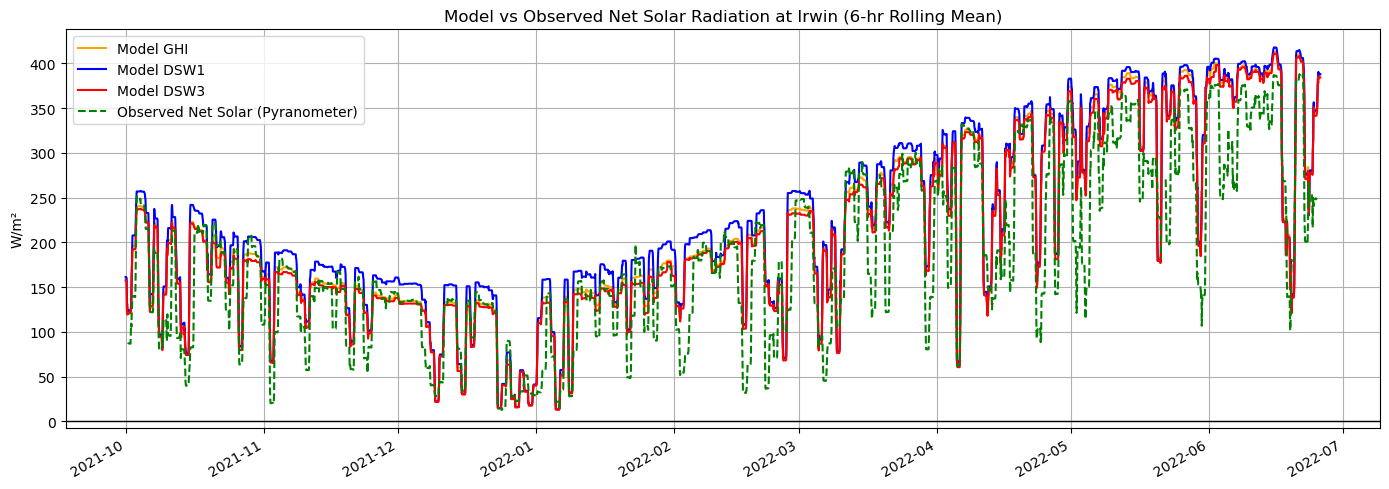

In [68]:
# plot full season
import matplotlib.pyplot as plt
import pandas as pd

# Define start and end of Water Year 2022
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Subset the DataFrame
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_wy2022 = irwin_pyra_hourly.loc[start_wy2022 : end_wy2022]
# irwin_pyra_hourly_wy2022 = irwin_pyra_hourly.loc['2021-10-01':'2022-09-30']

# Make sure the index of irwin_pyra is datetime
# Resample to hourly means
irwin_pyra_hourly_wy2022.index = pd.to_datetime(irwin_pyra_hourly_wy2022.index)

# Rolling mean for model outputs
win = 24
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean().loc[start_wy2022 : end_wy2022]
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean().loc[start_wy2022 : end_wy2022]
ghi_daily  = irwin_ghi.rolling(time=win, center=True).mean().loc[start_wy2022 : end_wy2022]

# Smooth the observed net solar radiation (e.g. 6-hour window = 24 points for 15-min data)
obs_net_solar = irwin_pyra_hourly_wy2022['VIS_IN'].rolling(window=win, center=True).mean()
obs_net_solar_ = obs_net_solar.where(obs_net_solar > 0 )

# Create the plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(dsw1_daily.time, ghi_daily, label='Model GHI', color='orange')
ax.plot(dsw1_daily.time, dsw1_daily, label='Model DSW1', color='blue')
ax.plot(dsw3_daily.time, dsw3_daily, label='Model DSW3', color='red')

# Plot station observation
ax.plot(obs_net_solar.index, obs_net_solar, label='Observed Net Solar (Pyranometer)', color='green', linestyle='--')

# Add zero reference line
ax.axhline(0, color='black', linewidth=1)

# Add labels, legend, formatting
ax.set_title('Model vs Observed Net Solar Radiation at Irwin (6-hr Rolling Mean)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Define start and end of Water Year 2022
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Resample observed data to hourly
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
obs_net_solar = irwin_pyra_hourly['VIS_IN'].loc[start_wy2022:end_wy2022]
obs_net_solar = obs_net_solar.where(obs_net_solar > 0)

# Align model data to same period and hourly frequency
dsw1 = irwin_dsw1.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
dsw3 = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
ghi  = irwin_ghi.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()

# Convert model times to datetime index if needed
dsw1 = dsw1.to_pandas()
dsw3 = dsw3.to_pandas()
ghi  = ghi.to_pandas()

# Combine all into a single DataFrame
df = pd.concat([obs_net_solar, dsw1, dsw3, ghi], axis=1)
df.columns = ['obs', 'dsw1', 'dsw3', 'ghi']
df = df.dropna()

# Compute bias (model - obs)
df['bias_dsw1'] = df['dsw1'] - df['obs']
df['bias_dsw3'] = df['dsw3'] - df['obs']
df['bias_ghi']  = df['ghi']  - df['obs']

# DAILY BIAS (W/m²·hr summed over day)
daily_bias = df.resample('D').sum()[['bias_dsw1', 'bias_dsw3', 'bias_ghi']]

# MONTHLY BIAS
monthly_bias = df.resample('ME').sum()[['bias_dsw1', 'bias_dsw3', 'bias_ghi']]

# SEASONAL TOTAL BIAS
seasonal_bias = df[['bias_dsw1', 'bias_dsw3', 'bias_ghi']].sum()

# DJF (Dec–Feb)
df_djf = df[(df.index.month == 12) | (df.index.month == 1) | (df.index.month == 2)]
djf_bias = df_djf[['bias_dsw1', 'bias_dsw3', 'bias_ghi']].sum()

# AMJ (Apr–Jun)
df_amj = df[(df.index.month >= 4) & (df.index.month <= 6)]
amj_bias = df_amj[['bias_dsw1', 'bias_dsw3', 'bias_ghi']].sum()

# Print results
print("=== Daily Bias Sample ===")
print(daily_bias.head())

print("\n=== Monthly Bias ===")
print(monthly_bias)

print("\n=== Seasonal Total Bias (W/m²·hr) ===")
print(seasonal_bias)

print("\n=== DJF Total Bias ===")
print(djf_bias)

print("\n=== AMJ Total Bias ===")
print(amj_bias)


=== Daily Bias Sample ===
              bias_dsw1    bias_dsw3     bias_ghi
2021-10-01   902.229167   829.469138   891.158988
2021-10-02  1463.329693  1212.315498  1242.272417
2021-10-03   148.187215  -328.318225  -247.549388
2021-10-04   342.172629  -139.229471   -62.447488
2021-10-05   546.243213   165.765896   258.162708

=== Monthly Bias ===
               bias_dsw1     bias_dsw3      bias_ghi
2021-10-31  24683.143116  13458.143179  16337.397581
2021-11-30  19502.107912   6806.558286   9074.782029
2021-12-31   9238.447854    566.657992   2213.777309
2022-01-31  23612.381697   9025.426674  13109.798470
2022-02-28  28508.594815  18118.071980  20137.262410
2022-03-31  29625.951779  19110.881534  22794.718601
2022-04-30  32064.113474  24940.076151  27711.551488
2022-05-31  51845.069656  44372.177529  48646.772072
2022-06-30  26664.600784  23037.847616  25071.832255

=== Seasonal Total Bias (W/m²·hr) ===
bias_dsw1    245744.411087
bias_dsw3    159435.840942
bias_ghi     185097.892216
dt

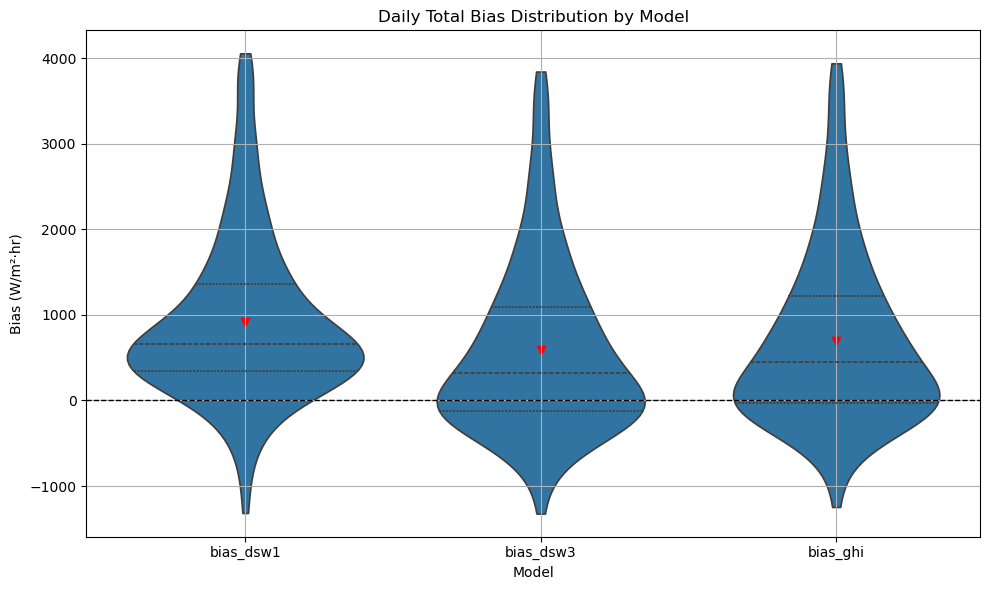

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import CategoricalDtype

# =========================
# DAILY BIAS BOXPLOT
# =========================
# Reset and reshape daily bias
# daily_bias_long = daily_bias.reset_index().rename(columns={'index': 'Date'})
# daily_bias_long = daily_bias_long.melt(id_vars='Date', var_name='Model', value_name='Bias')

# # Plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Model', y='Bias', data=daily_bias_long)
# plt.title('Daily Total Bias Distribution by Model')
# plt.ylabel('Bias (W/m²·hr)')
# plt.axhline(0, color='black', linestyle='--', linewidth=1)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# Prepare the data (same as before)
daily_bias_long = daily_bias.reset_index().rename(columns={'index': 'Date'})
daily_bias_long = daily_bias_long.melt(id_vars='Date', var_name='Model', value_name='Bias')

# Plot as violin
plt.figure(figsize=(10, 6))
sns.violinplot(x='Model', y='Bias', data=daily_bias_long, inner='quartile', cut=0)

model_order = daily_bias_long['Model'].unique()  # Ensure this matches the x-axis order
means = daily_bias_long.groupby('Model')['Bias'].mean().reindex(model_order)

# Plot the means as red dots
plt.scatter(range(len(model_order)), means.values, color='red', marker='v', linestyle='-', label='Mean')


plt.title('Daily Total Bias Distribution by Model')
plt.ylabel('Bias (W/m²·hr)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True)
plt.tight_layout()
plt.show()


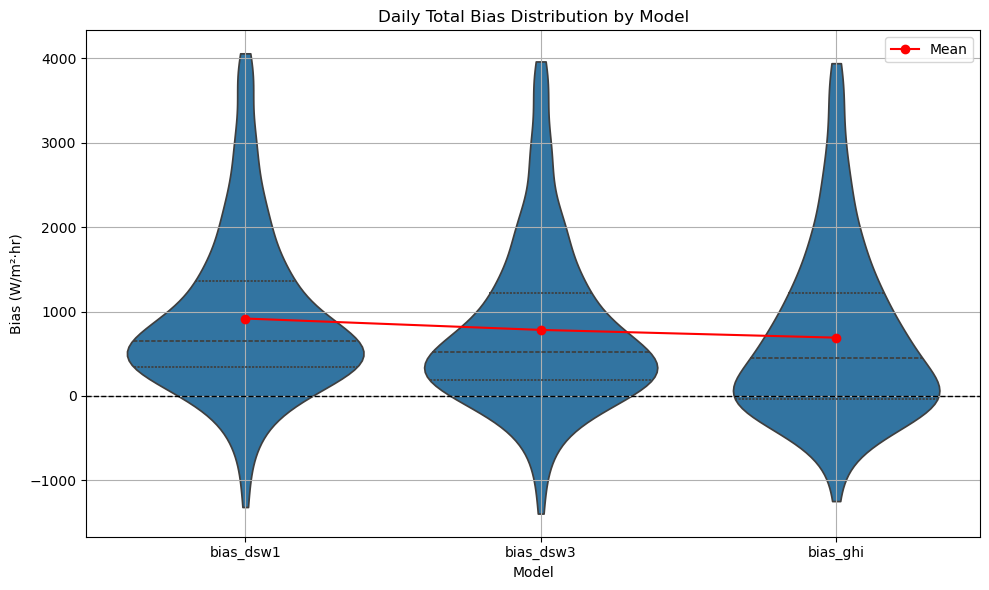

In [52]:
# Prepare the data
daily_bias_long = daily_bias.reset_index().rename(columns={'index': 'Date'})
daily_bias_long = daily_bias_long.melt(id_vars='Date', var_name='Model', value_name='Bias')

# Create the violin plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='Model', y='Bias', data=daily_bias_long, inner='quartile', cut=0)

# Calculate means
model_order = daily_bias_long['Model'].unique()  # Ensure this matches the x-axis order
means = daily_bias_long.groupby('Model')['Bias'].mean().reindex(model_order)

# Plot the means as red dots
plt.plot(range(len(model_order)), means.values, color='red', marker='o', linestyle='-', label='Mean')

# Final touches
plt.title('Daily Total Bias Distribution by Model')
plt.ylabel('Bias (W/m²·hr)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Observed datetime range: 2021-10-01 00:00:00 to 2022-06-25 14:00:00
DSW1 datetime range: 2021-09-30T06:00:00.000000000 to 2022-08-01T05:00:00.000000000
DSW3 datetime range: 2021-09-30T06:00:00.000000000 to 2022-08-01T05:00:00.000000000
GHI  datetime range: 2021-09-30T06:00:00.000000000 to 2022-08-01T05:00:00.000000000
Aligned timestamps: 6423 of 6423 available


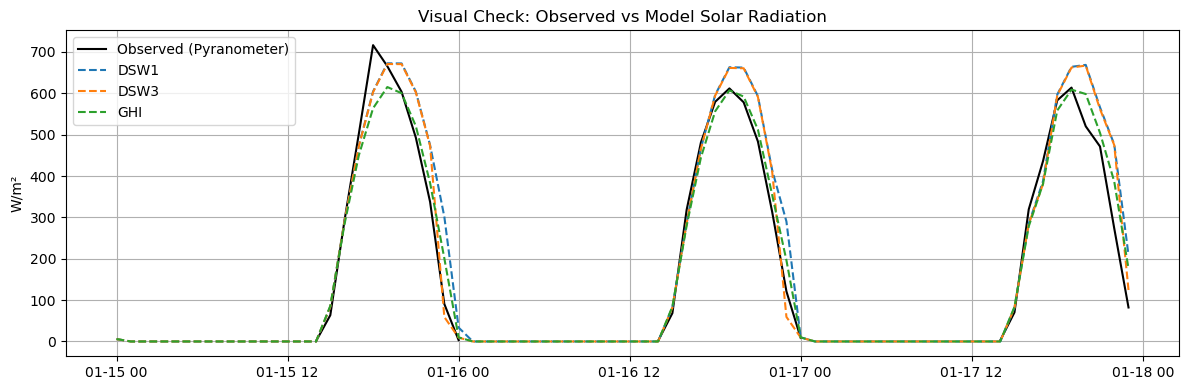

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Check datetime ranges ===
print("Observed datetime range:", obs_net_solar.index.min(), "to", obs_net_solar.index.max())
print("DSW1 datetime range:", irwin_dsw1.time.min().values, "to", irwin_dsw1.time.max().values)
print("DSW3 datetime range:", irwin_dsw3.time.min().values, "to", irwin_dsw3.time.max().values)
print("GHI  datetime range:", irwin_ghi.time.min().values, "to", irwin_ghi.time.max().values)

# === 2. Convert model DataArrays to Series and ensure datetime index ===
dsw1 = irwin_dsw1.to_series()
dsw3 = irwin_dsw3.to_series()
ghi  = irwin_ghi.to_series()

dsw1.index = pd.to_datetime(dsw1.index)
dsw3.index = pd.to_datetime(dsw3.index)
ghi.index  = pd.to_datetime(ghi.index)

# === 3. Align all series on the common datetime index ===
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)

print(f"Aligned timestamps: {len(common_index)} of {len(obs_net_solar.index)} available")

obs_aligned  = obs_net_solar.loc[common_index]
dsw1_aligned = dsw1.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]
ghi_aligned  = ghi.loc[common_index]

# === 4. Calculate Bias ===
bias_dsw1 = dsw1_aligned - obs_aligned
bias_dsw3 = dsw3_aligned - obs_aligned
bias_ghi  = ghi_aligned  - obs_aligned

# === 5. Optional: Visual check of alignment ===
start_check = '2022-01-15'
end_check   = '2022-01-17'

plt.figure(figsize=(12, 4))
plt.plot(obs_aligned.loc[start_check:end_check], label='Observed (Pyranometer)', color='black')
plt.plot(dsw1_aligned.loc[start_check:end_check], label='DSW1', linestyle='--')
plt.plot(dsw3_aligned.loc[start_check:end_check], label='DSW3', linestyle='--')
plt.plot(ghi_aligned.loc[start_check:end_check], label='GHI', linestyle='--')
plt.title('Visual Check: Observed vs Model Solar Radiation')
plt.ylabel('W/m²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


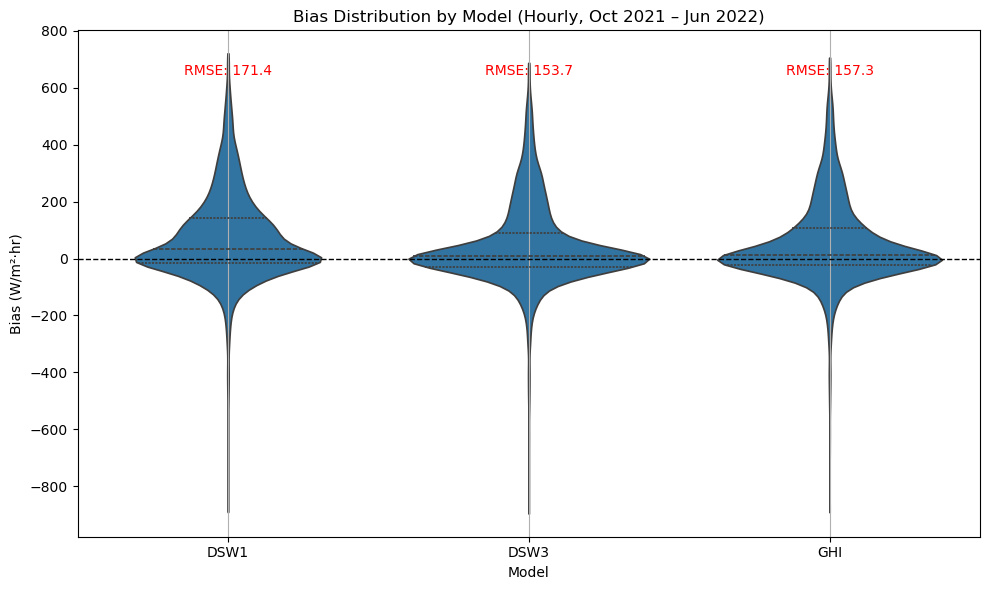

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define water year range
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# 1. Align observed and modeled data on common datetime index
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw1_aligned = dsw1.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]
ghi_aligned  = ghi.loc[common_index]

# 2. Filter to desired date range
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw1_filtered = dsw1_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]

# 3. Remove times when observed values are zero or negative
valid = obs_filtered > 0
obs_valid  = obs_filtered[valid]
dsw1_valid = dsw1_filtered[valid]
dsw3_valid = dsw3_filtered[valid]
ghi_valid  = ghi_filtered[valid]

# 4. Calculate bias
bias_dsw1 = dsw1_valid - obs_valid
bias_dsw3 = dsw3_valid - obs_valid
bias_ghi  = ghi_valid  - obs_valid

# 5. Combine into long-format DataFrame for plotting
bias_df = pd.DataFrame({
    'DSW1': bias_dsw1,
    'DSW3': bias_dsw3,
    'GHI':  bias_ghi
})
bias_long = bias_df.melt(var_name='Model', value_name='Bias')

# 6. Compute RMSE per model
rmse_values = bias_df.apply(lambda x: np.sqrt(np.mean(x**2)))
rmse_labels = [f'RMSE: {rmse_values[model]:.1f}' for model in bias_df.columns]

# 7. Plot violin plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='Model', y='Bias', data=bias_long, inner='quartile', cut=0)

# Add RMSE text annotations
for i, label in enumerate(rmse_labels):
    ax.text(i, bias_long['Bias'].max() * 0.95, label,
            ha='center', va='top', fontsize=10, color='red')

# Final formatting
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Bias Distribution by Model (Hourly, Oct 2021 – Jun 2022)')
plt.ylabel('Bias (W/m²·hr)')
ax.grid(axis='x')  # Only vertical grid lines
plt.tight_layout()
plt.show()


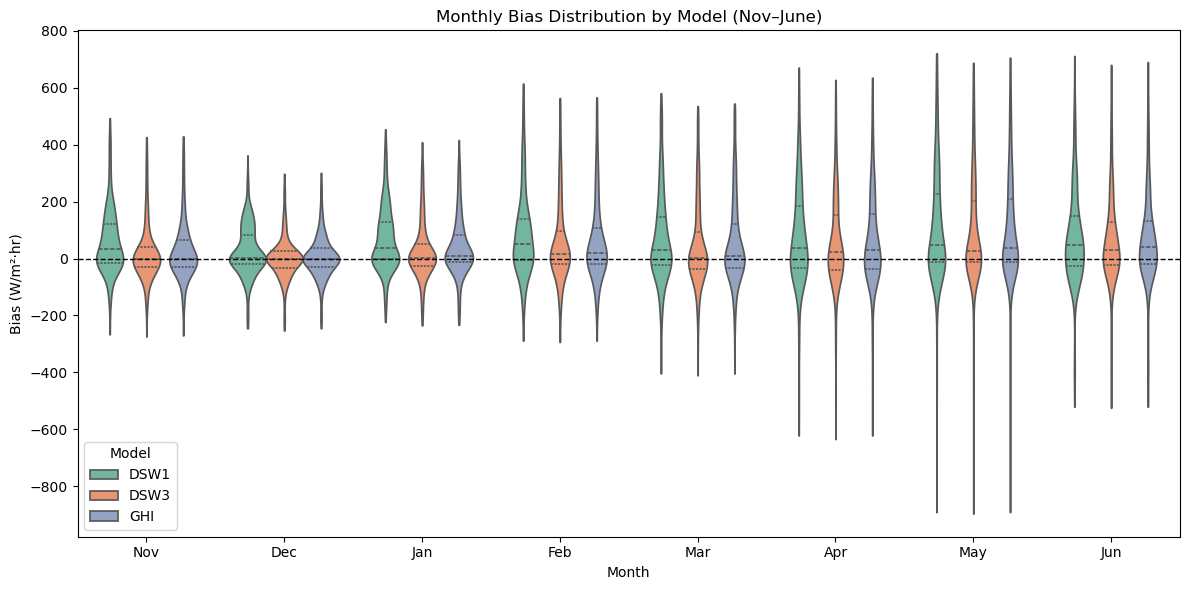

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Setup: Align and filter ---
# Define full water year range
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Align data
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw1_aligned = dsw1.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]
ghi_aligned  = ghi.loc[common_index]

# Filter to WY2022
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw1_filtered = dsw1_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]

# Remove zero or negative observed values
valid = obs_filtered > 0
obs_valid  = obs_filtered[valid]
dsw1_valid = dsw1_filtered[valid]
dsw3_valid = dsw3_filtered[valid]
ghi_valid  = ghi_filtered[valid]

# --- Bias and Monthly Label ---
bias_df = pd.DataFrame({
    'DSW1': dsw1_valid - obs_valid,
    'DSW3': dsw3_valid - obs_valid,
    'GHI':  ghi_valid  - obs_valid
})
bias_df['Month'] = bias_df.index.month

# Keep only Nov–June
bias_df = bias_df[bias_df['Month'].isin([11, 12, 1, 2, 3, 4, 5, 6])]
bias_df['Month'] = bias_df['Month'].map({
    11: 'Nov', 12: 'Dec', 1: 'Jan', 2: 'Feb',
    3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun'
})

# Melt to long format for plotting
bias_long = bias_df.melt(id_vars='Month', var_name='Model', value_name='Bias')

# --- Violin Plot ---
plt.figure(figsize=(12, 6))
sns.violinplot(x='Month', y='Bias', hue='Model', data=bias_long, split=False,
               inner='quartile', cut=0, palette='Set2')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Monthly Bias Distribution by Model (Nov–June)')
plt.ylabel('Bias (W/m²·hr)')
plt.xlabel('Month')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


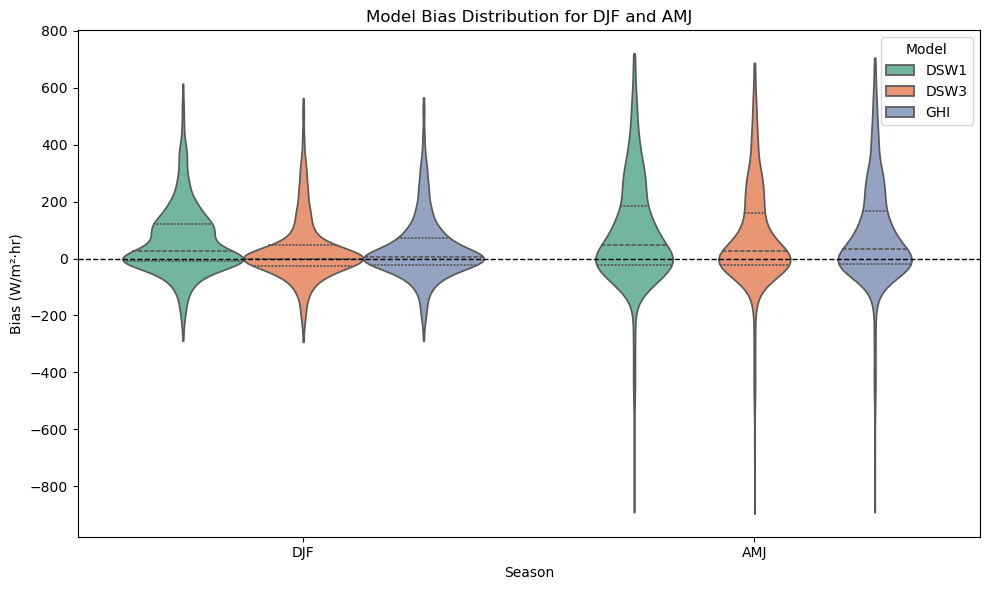

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Setup: align and filter ---
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw1_aligned = dsw1.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]
ghi_aligned  = ghi.loc[common_index]

mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw1_filtered = dsw1_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]

# Keep only positive observed values
valid = obs_filtered > 0
obs_valid  = obs_filtered[valid]
dsw1_valid = dsw1_filtered[valid]
dsw3_valid = dsw3_filtered[valid]
ghi_valid  = ghi_filtered[valid]

# --- Bias and Season Label ---
bias_df = pd.DataFrame({
    'DSW1': dsw1_valid - obs_valid,
    'DSW3': dsw3_valid - obs_valid,
    'GHI':  ghi_valid  - obs_valid
}, index=obs_valid.index)

# Map months to DJF / AMJ
month_to_season = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ'
}
bias_df['Season'] = bias_df.index.month.map(month_to_season)

# Filter out rows that are not in DJF or AMJ
bias_df = bias_df[bias_df['Season'].notna()]

# Melt to long format (after removing any unnecessary columns)
bias_long = bias_df.melt(id_vars='Season', var_name='Model', value_name='Bias')

# --- Violin Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(x='Season', y='Bias', hue='Model', data=bias_long,
               inner='quartile', cut=0, palette='Set2')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Model Bias Distribution for DJF and AMJ')
plt.ylabel('Bias (W/m²·hr)')
plt.xlabel('Season')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

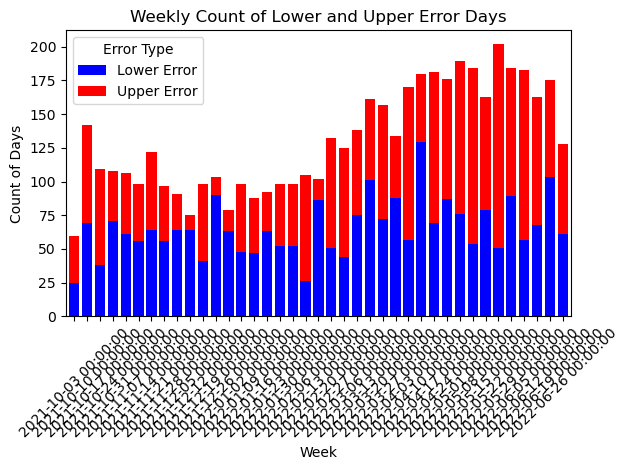

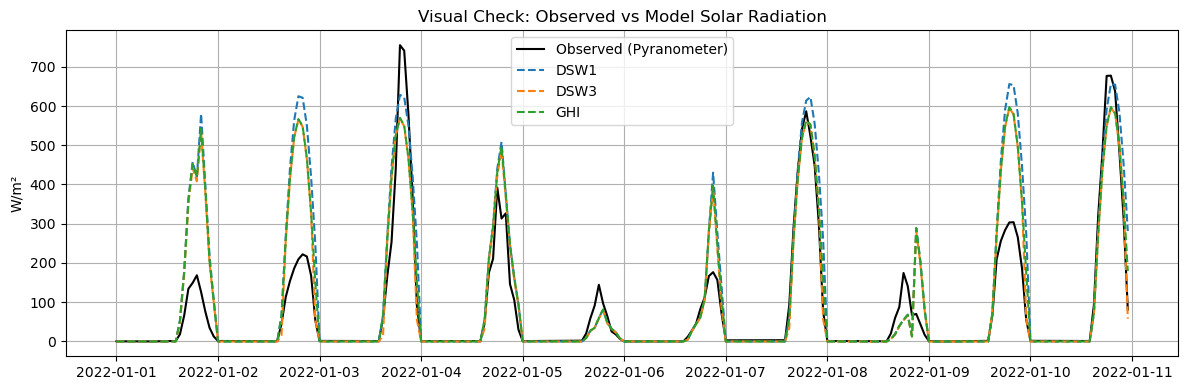

In [74]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # --- Setup: Align and filter data ---
# start_wy2022 = '2021-10-01'
# end_wy2022   = '2022-06-25'

# # Ensure data is aligned to the common index
# common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
# obs_aligned  = obs_net_solar.loc[common_index]
# dsw1_aligned = dsw1.loc[common_index]
# dsw3_aligned = dsw3.loc[common_index]
# ghi_aligned  = ghi.loc[common_index]

# # Filter data based on the given date range
# mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
# obs_filtered  = obs_aligned.loc[mask]
# dsw1_filtered = dsw1_aligned.loc[mask]
# dsw3_filtered = dsw3_aligned.loc[mask]
# ghi_filtered  = ghi_aligned.loc[mask]

# # Keep only positive observed values
# valid = (obs_filtered > 0)
# obs_valid  = obs_filtered[valid]
# dsw1_valid = dsw1_filtered[valid]
# dsw3_valid = dsw3_filtered[valid]
# ghi_valid  = ghi_filtered[valid]

# # --- Calculate bias ---
# bias_df = pd.DataFrame({
#     'DSW1': dsw1_valid - obs_valid,
#     'DSW3': dsw3_valid - obs_valid,
#     'GHI':  ghi_valid  - obs_valid
# }, index=obs_valid.index)

# # --- Find lower and upper 25% (quantiles) ---
# lower_quantile = bias_df.quantile(0.25, axis=0)
# upper_quantile = bias_df.quantile(0.75, axis=0)

# # Determine which days fall into the lower and upper quantiles for each model
# lower_error_days = (bias_df <= lower_quantile).sum(axis=1)
# upper_error_days = (bias_df >= upper_quantile).sum(axis=1)

# # Merge lower and upper errors into a single DataFrame
# error_days_df = pd.DataFrame({
#     'Lower Error': lower_error_days,
#     'Upper Error': upper_error_days
# })

# # --- Plot count by week ---
# # Resample to weekly frequency
# error_days_weekly = error_days_df.resample('W').sum()

# # Bar chart showing the count of days in lower/upper error range per week
# plt.figure(figsize=(12, 6))
# error_days_weekly.plot(kind='bar', stacked=True, color=['blue', 'red'], width=0.8)
# plt.title('Weekly Count of Lower and Upper Error Days')
# plt.ylabel('Count of Days')
# plt.xlabel('Week')
# plt.xticks(rotation=45)
# plt.legend(title='Error Type')
# plt.tight_layout()
# plt.show()

# # --- Plot the side-by-side comparison for the greatest error days ---
# # Select the period for visual inspection (you can adjust the start and end dates)
# start_check = '2022-01-01'
# end_check   = '2022-01-10'

# # Plot side-by-side line charts for each model
# plt.figure(figsize=(12, 4))

# # Plot the observed data
# plt.plot(obs_valid.loc[start_check:end_check], label='Observed (Pyranometer)', color='black')

# # Plot model outputs (DSW1, DSW3, GHI)
# plt.plot(dsw1_valid.loc[start_check:end_check], label='DSW1', linestyle='--')
# plt.plot(dsw3_valid.loc[start_check:end_check], label='DSW3', linestyle='--')
# plt.plot(ghi_valid.loc[start_check:end_check], label='GHI', linestyle='--')

# # Formatting the plot
# plt.title('Visual Check: Observed vs Model Solar Radiation')
# plt.ylabel('W/m²')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


<Figure size 1200x600 with 0 Axes>

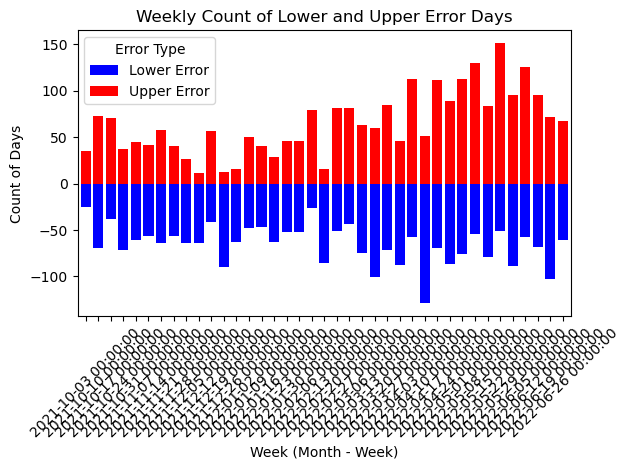

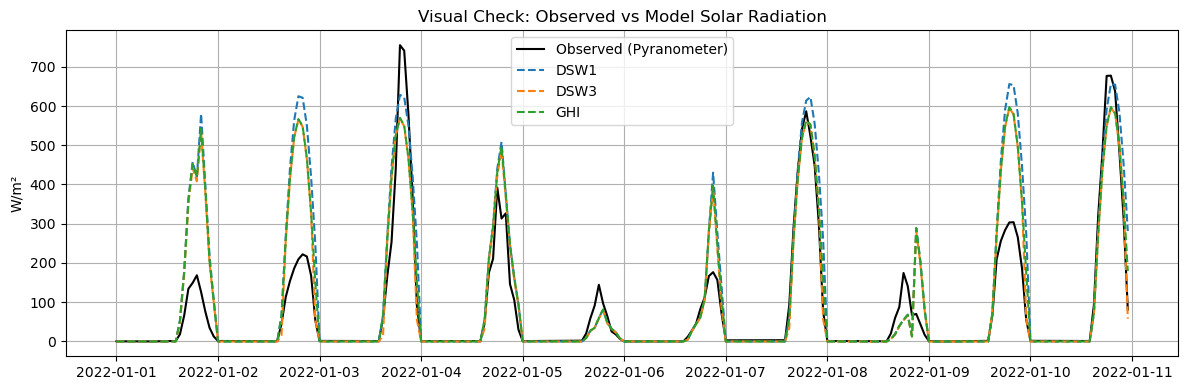

In [75]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # --- Setup: Align and filter data ---
# start_wy2022 = '2021-10-01'
# end_wy2022   = '2022-06-25'

# # Ensure data is aligned to the common index
# common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
# obs_aligned  = obs_net_solar.loc[common_index]
# dsw1_aligned = dsw1.loc[common_index]
# dsw3_aligned = dsw3.loc[common_index]
# ghi_aligned  = ghi.loc[common_index]

# # Filter data based on the given date range
# mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
# obs_filtered  = obs_aligned.loc[mask]
# dsw1_filtered = dsw1_aligned.loc[mask]
# dsw3_filtered = dsw3_aligned.loc[mask]
# ghi_filtered  = ghi_aligned.loc[mask]

# # Keep only positive observed values
# valid = (obs_filtered > 0)
# obs_valid  = obs_filtered[valid]
# dsw1_valid = dsw1_filtered[valid]
# dsw3_valid = dsw3_filtered[valid]
# ghi_valid  = ghi_filtered[valid]

# # --- Calculate bias ---
# bias_df = pd.DataFrame({
#     'DSW1': dsw1_valid - obs_valid,
#     'DSW3': dsw3_valid - obs_valid,
#     'GHI':  ghi_valid  - obs_valid
# }, index=obs_valid.index)

# # --- Find lower and upper 25% (quantiles) ---
# lower_quantile = bias_df.quantile(0.25, axis=0)
# upper_quantile = bias_df.quantile(0.75, axis=0)

# # Determine which days fall into the lower and upper quantiles for each model
# lower_error_days = (bias_df <= lower_quantile).sum(axis=1)
# upper_error_days = (bias_df >= upper_quantile).sum(axis=1)

# # Merge lower and upper errors into a single DataFrame
# error_days_df = pd.DataFrame({
#     'Lower Error': lower_error_days,
#     'Upper Error': upper_error_days
# })

# # --- Resample to weekly count of error days ---
# # Resample to weekly frequency and sum the counts, ensuring only full days are counted
# error_days_weekly = error_days_df.resample('W').sum()

# # Count negative error days as negative and positive error days as positive
# error_days_weekly['Lower Error'] = -error_days_weekly['Lower Error']

# # --- Plot count by week with month-week format ---
# plt.figure(figsize=(12, 6))
# error_days_weekly.plot(kind='bar', stacked=True, color=['blue', 'red'], width=0.8)

# # Custom x-axis labels for month-week format
# error_days_weekly.index = error_days_weekly.index.strftime('%b %d-%d')
# plt.xticks(rotation=45)

# # Plot title and labels
# plt.title('Weekly Count of Lower and Upper Error Days')
# plt.ylabel('Count of Days')
# plt.xlabel('Week (Month - Week)')

# # Display legend
# plt.legend(title='Error Type')
# plt.tight_layout()
# plt.show()

# --- Plot the side-by-side comparison for the greatest error days ---
# Select the period for visual inspection (you can adjust the start and end dates)
start_check = '2022-01-01'
end_check   = '2022-01-10'

# Plot side-by-side line charts for each model
plt.figure(figsize=(12, 4))

# Plot the observed data
plt.plot(obs_valid.loc[start_check:end_check], label='Observed (Pyranometer)', color='black')

# Plot model outputs (DSW1, DSW3, GHI)
plt.plot(dsw1_valid.loc[start_check:end_check], label='DSW1', linestyle='--')
plt.plot(dsw3_valid.loc[start_check:end_check], label='DSW3', linestyle='--')
plt.plot(ghi_valid.loc[start_check:end_check], label='GHI', linestyle='--')

# Formatting the plot
plt.title('Visual Check: Observed vs Model Solar Radiation')
plt.ylabel('W/m²')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

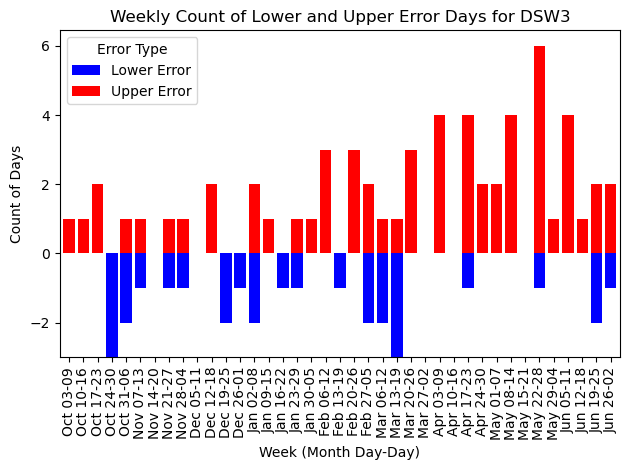

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Setup: Align and filter data ---
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Ensure data is aligned to the common index
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]

# Filter data based on the given date range
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]

# Keep only positive observed values
valid = (obs_filtered > 0)
obs_valid  = obs_filtered[valid]
dsw3_valid = dsw3_filtered[valid]

# --- Calculate bias for DSW3 ---
bias_dsw3 = dsw3_valid - obs_valid

# --- Find lower and upper 25% (quantiles) ---
lower_quantile = bias_dsw3.quantile(0.25)
upper_quantile = bias_dsw3.quantile(0.75)

# --- Determine which days fall into the lower and upper quantiles ---
# Resample to daily frequency and check if daily bias falls into lower or upper quantiles
daily_bias = bias_dsw3.resample('D').apply(lambda x: x.mean())  # Use daily mean of the bias

lower_error_days = daily_bias <= lower_quantile
upper_error_days = daily_bias >= upper_quantile

# Create a DataFrame for error days
error_days_df = pd.DataFrame({
    'Lower Error': lower_error_days,
    'Upper Error': upper_error_days
})

# --- Resample by week and count error days ---
# Resample weekly and count how many days each week have lower and upper errors
error_days_weekly = error_days_df.resample('W').sum()

# Count negative error days as negative and positive error days as positive
error_days_weekly['Lower Error'] = -error_days_weekly['Lower Error']

# --- Format X-axis labels to Month Day-Day (e.g., Oct 3-9) ---
# Create custom labels based on the start and end of each week
week_labels = []
for start_date in error_days_weekly.index:
    start_str = start_date.strftime('%b %d')
    end_date = start_date + pd.DateOffset(days=6)
    end_str = end_date.strftime('%d')
    week_labels.append(f"{start_str}-{end_str}")

# --- Plot count by week with month-week format ---
plt.figure(figsize=(12, 6))

# Plot the bar chart with the stacked counts of Lower and Upper Error days
error_days_weekly.plot(kind='bar', stacked=True, color=['blue', 'red'], width=0.8)

# Set custom x-tick labels
plt.xticks(range(len(week_labels)), week_labels, rotation=90)

# Plot title and labels
plt.title('Weekly Count of Lower and Upper Error Days for DSW3')
plt.ylabel('Count of Days')
plt.xlabel('Week (Month Day-Day)')

# Display legend
plt.legend(title='Error Type')

# Show plot
plt.tight_layout()
plt.show()


/scratch/local/u1037042/4232199/ipykernel_2261952/1541733012.py:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  error_days_monthly = error_days_df.resample('M').sum()


<Figure size 1200x600 with 0 Axes>

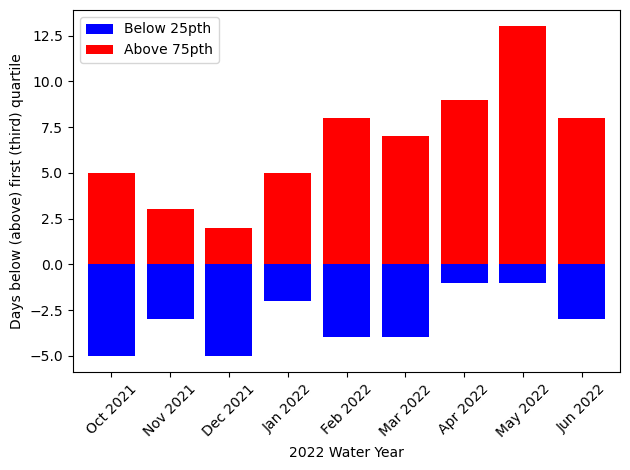

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Setup: Align and filter data ---
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Ensure data is aligned to the common index
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]

# Filter data based on the given date range
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]

# Keep only positive observed values
valid = (obs_filtered > 0)
obs_valid  = obs_filtered[valid]
dsw3_valid = dsw3_filtered[valid]

# --- Calculate bias for DSW3 ---
bias_dsw3 = dsw3_valid - obs_valid

# --- Find lower and upper 25% (quantiles) ---
lower_quantile = bias_dsw3.quantile(0.25)
upper_quantile = bias_dsw3.quantile(0.75)

# --- Determine which days fall into the lower and upper quantiles ---
# Resample to daily frequency and check if daily bias falls into lower or upper quantiles
daily_bias = bias_dsw3.resample('D').apply(lambda x: x.mean())  # Use daily mean of the bias

lower_error_days = daily_bias <= lower_quantile
upper_error_days = daily_bias >= upper_quantile

# Create a DataFrame for error days
error_days_df = pd.DataFrame({
    'Lower Error': lower_error_days,
    'Upper Error': upper_error_days
})

# --- Resample by month and count error days ---
# Resample monthly and count how many days each month have lower and upper errors
error_days_monthly = error_days_df.resample('M').sum()

# Count negative error days as negative and positive error days as positive
error_days_monthly['Lower Error'] = -error_days_monthly['Lower Error']

# --- Format X-axis labels to Month-Year (e.g., Oct 2021) ---
# Create custom labels for each month
month_labels = [date.strftime('%b %Y') for date in error_days_monthly.index]

# --- Plot count by month with month format ---
plt.figure(figsize=(12, 6))

# Plot the bar chart with the stacked counts of Lower and Upper Error days
error_days_monthly.plot(kind='bar', stacked=True, color=['blue', 'red'], width=0.8)

# Set custom x-tick labels
plt.xticks(range(len(month_labels)), month_labels, rotation=45)

# Plot title and labels
# plt.title('Monthly Count of Lower and Upper Error Days for DSW3')
plt.ylabel('Days below (above) first (third) quartile')
plt.xlabel('2022 Water Year')

# Display legend
# plt.legend(title='Error Type')
plt.legend(title='', labels=['Below 25pth', 'Above 75pth'])

# Show plot
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

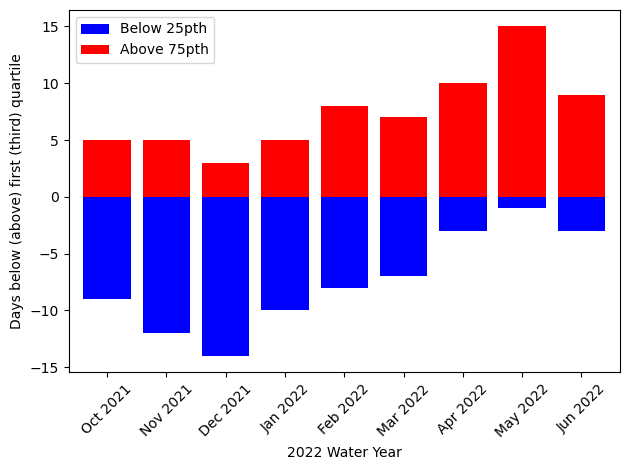

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Setup: Align and filter data ---
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

# Ensure data is aligned to the common index
common_index = obs_net_solar.index.intersection(dsw1.index).intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]

# Filter data based on the given date range
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]

# Keep only positive observed values
valid = (obs_filtered > 0)
obs_valid  = obs_filtered[valid]
dsw3_valid = dsw3_filtered[valid]

# --- Calculate bias for DSW3 ---
bias_dsw3 = dsw3_valid - obs_valid

# --- Resample to daily bias and drop NaNs ---
daily_bias = bias_dsw3.resample('D').mean().dropna()

# --- Find lower and upper 25% (quantiles) ---
lower_quantile = daily_bias.quantile(0.25)
upper_quantile = daily_bias.quantile(0.75)

# --- Determine which days fall into lower and upper quantiles ---
lower_error_days = daily_bias <= lower_quantile
upper_error_days = daily_bias >= upper_quantile

# Create DataFrame and ensure booleans are cast to integers (True=1, False=0)
error_days_df = pd.DataFrame({
    'Lower Error': lower_error_days.astype(int),
    'Upper Error': upper_error_days.astype(int)
})

# --- Resample by month and count error days ---
error_days_monthly = error_days_df.resample('ME').sum()

# Count negative error days as negative
error_days_monthly['Lower Error'] = -error_days_monthly['Lower Error']

# --- Custom x-axis labels: month and year ---
month_labels = [d.strftime('%b %Y') for d in error_days_monthly.index]

# --- Plot ---
plt.figure(figsize=(12, 6))
error_days_monthly.plot(kind='bar', stacked=True, color=['blue', 'red'], width=0.8)

plt.xticks(range(len(month_labels)), month_labels, rotation=45)
plt.ylabel('Days below (above) first (third) quartile')
plt.xlabel('2022 Water Year')
plt.legend(title='', labels=['Below 25pth', 'Above 75pth'])
plt.tight_layout()
plt.show()


In [80]:
print(f"Lower 25th percentile bias (Q1): {lower_quantile:.2f}")
print(f"Upper 75th percentile bias (Q3): {upper_quantile:.2f}")


Lower 25th percentile bias (Q1): -10.44
Upper 75th percentile bias (Q3): 83.27


In [81]:
print("Count of days:")
print("  Below 25th percentile:", lower_error_days.sum())
print("  Above 75th percentile:", upper_error_days.sum())
print("  Total daily bias records:", len(daily_bias))


Count of days:
  Below 25th percentile: 67
  Above 75th percentile: 67
  Total daily bias records: 268


Standard deviation of daily bias: 71.66 W/m²·hr


<Figure size 1200x600 with 0 Axes>

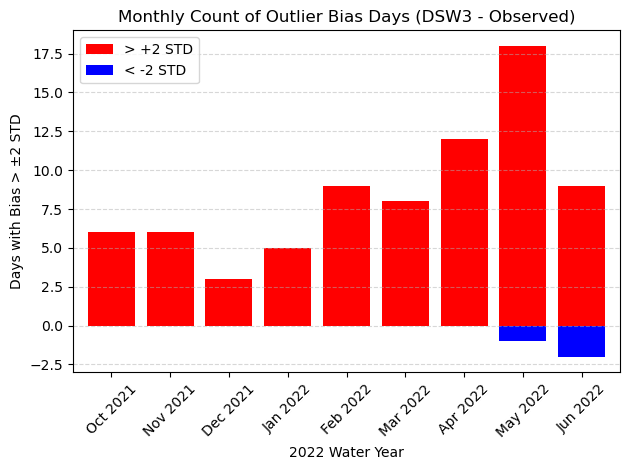

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Setup: Filter and align data ---
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-06-25'

common_index = obs_net_solar.index.intersection(dsw3.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]

# Filter date range and remove zero or negative obs
mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
valid_mask    = obs_filtered > 0
obs_valid     = obs_filtered[valid_mask]
dsw3_valid    = dsw3_filtered[valid_mask]

# --- Calculate bias and resample to daily mean ---
bias_dsw3 = dsw3_valid - obs_valid
daily_bias = bias_dsw3.resample('D').mean().dropna()

# --- Compute standard deviation ---
bias_std = daily_bias.std()
print(f"Standard deviation of daily bias: {bias_std:.2f} W/m²·hr")

# --- Identify days beyond ±2 std dev ---
high_error_days = daily_bias > (1 * bias_std)
low_error_days  = daily_bias < (-1 * bias_std)

# --- Create DataFrame for monthly count ---
error_flags_df = pd.DataFrame({
    'High Error': high_error_days.astype(int),
    'Low Error': low_error_days.astype(int)
})

# Count days by month
monthly_errors = error_flags_df.resample('ME').sum()

# Flip low errors negative for visual contrast
monthly_errors['Low Error'] = -monthly_errors['Low Error']

# X-axis labels
month_labels = [d.strftime('%b %Y') for d in monthly_errors.index]

# --- Plot ---
plt.figure(figsize=(12, 6))
monthly_errors.plot(kind='bar', stacked=True, color=['red', 'blue'], width=0.8)

plt.xticks(range(len(month_labels)), month_labels, rotation=45)
plt.ylabel('Days with Bias > ±2 STD')
plt.xlabel('2022 Water Year')
plt.legend(labels=['> +2 STD', '< -2 STD'], title='')
plt.title('Monthly Count of Outlier Bias Days (DSW3 - Observed)')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


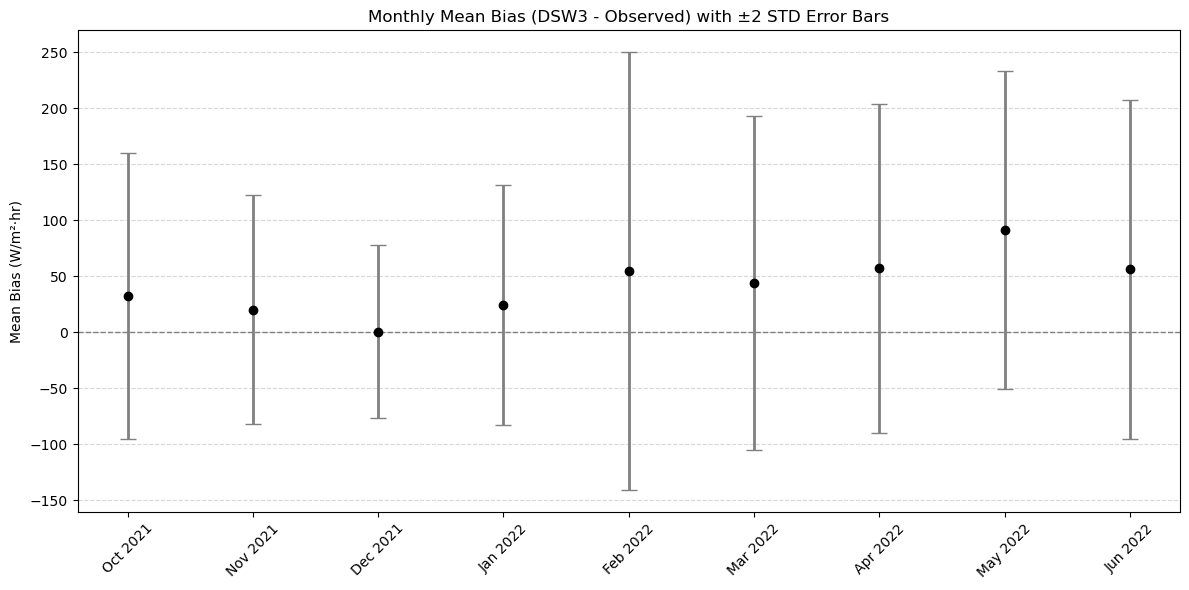

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Calculate monthly mean and std deviation ---
monthly_stats = daily_bias.resample('ME').agg(['mean', 'std'])

# Calculate ±2 standard deviations
monthly_stats['+2std'] = monthly_stats['std'] * 2
monthly_stats['-2std'] = monthly_stats['std'] * 2  # Symmetric, but optional

# Extract values for plotting
months = monthly_stats.index
means = monthly_stats['mean']
errors = monthly_stats['+2std']

# Format month labels
month_labels = [date.strftime('%b %Y') for date in months]

# --- Plot mean with ±2 STD error bars ---
plt.figure(figsize=(12, 6))
plt.errorbar(month_labels, means, yerr=errors, fmt='o', capsize=6, color='black', ecolor='gray', elinewidth=2)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Mean Bias (W/m²·hr)')
plt.title('Monthly Mean Bias (DSW3 - Observed) with ±2 STD Error Bars')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Assuming you already have this setup from before:
# daily_bias_dsw3 = dsw3_valid - obs_valid
# daily_bias_ghi = ghi_valid - obs_valid

# Resample to daily and calculate bias (do this if not done yet)
daily_bias_dsw3 = (dsw3 - obs_net_solar).resample('D').mean()
daily_bias_ghi = (ghi - obs_net_solar).resample('D').mean()

# Remove NaNs
daily_bias_dsw3 = daily_bias_dsw3.dropna()
daily_bias_ghi = daily_bias_ghi.dropna()

# Compute monthly stats for each model
monthly_stats_dsw3 = daily_bias_dsw3.resample('ME').agg(['mean', 'std'])
monthly_stats_ghi  = daily_bias_ghi.resample('ME').agg(['mean', 'std'])

# Compute ±2 standard deviation error bars
monthly_stats_dsw3['+2std'] = monthly_stats_dsw3['std'] * 1
monthly_stats_ghi['+2std'] = monthly_stats_ghi['std'] * 1

# Get values for plotting
months = monthly_stats_dsw3.index
month_labels = [date.strftime('%b %Y') for date in months]

means_dsw3 = monthly_stats_dsw3['mean']
errors_dsw3 = monthly_stats_dsw3['+2std']

means_ghi = monthly_stats_ghi['mean']
errors_ghi = monthly_stats_ghi['+2std']


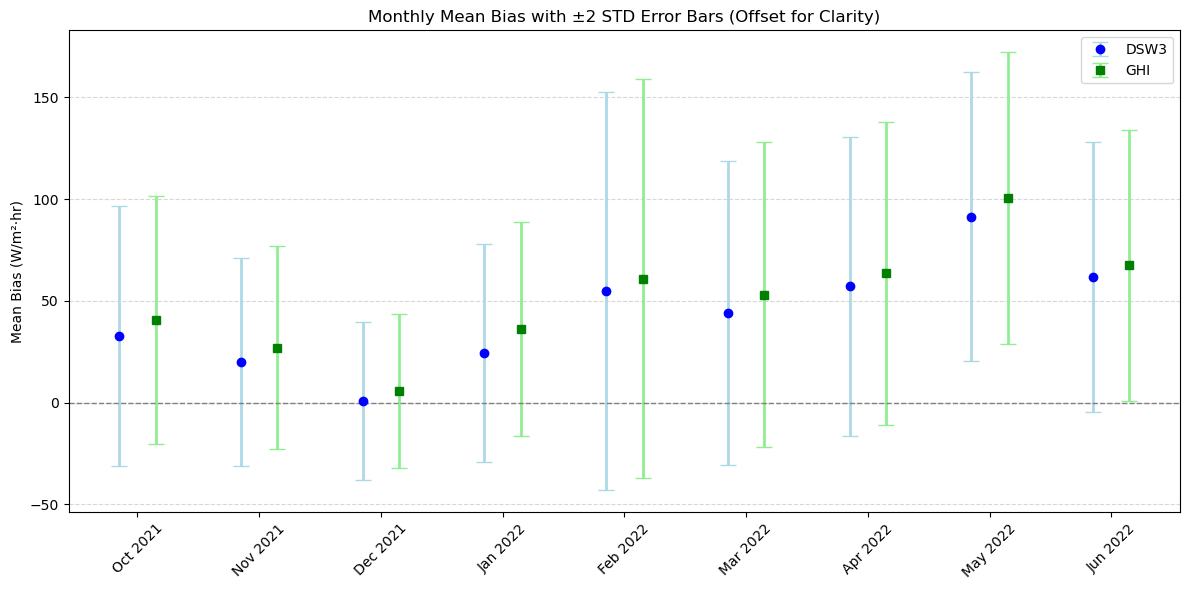

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# --- Numeric positions for months ---
x = np.arange(len(months))  # 0, 1, 2, ..., N months
offset = 0.15  # Offset value for separation

# --- Plot ---
plt.figure(figsize=(12, 6))

# DSW3: shifted slightly left
plt.errorbar(x - offset, means_dsw3, yerr=errors_dsw3,
             fmt='o', capsize=6, color='blue', label='DSW3',
             ecolor='lightblue', elinewidth=2)

# GHI: shifted slightly right
plt.errorbar(x + offset, means_ghi, yerr=errors_ghi,
             fmt='s', capsize=6, color='green', label='GHI',
             ecolor='lightgreen', elinewidth=2)

# Format x-axis
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xticks(ticks=x, labels=month_labels, rotation=45)
plt.ylabel('Mean Bias (W/m²·hr)')
plt.title('Monthly Mean Bias with ±2 STD Error Bars (Offset for Clarity)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtered data assumed: obs_net_solar, dsw3, ghi (as pandas Series with datetime index)
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# Align and subset
common_index = obs_net_solar.index.intersection(dsw3.index).intersection(ghi.index)
obs_aligned  = obs_net_solar.loc[common_index]
dsw3_aligned = dsw3.loc[common_index]
ghi_aligned  = ghi.loc[common_index]

mask = (obs_aligned.index >= start_wy2022) & (obs_aligned.index <= end_wy2022)
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]

valid = obs_filtered > 0
obs_valid  = obs_filtered[valid]
dsw3_valid = dsw3_filtered[valid]
ghi_valid  = ghi_filtered[valid]

# Diurnal patterns
hourly_bias = pd.DataFrame({
    'DSW3 Bias': (dsw3_valid - obs_valid).groupby(obs_valid.index.hour).mean(),
    'GHI Bias':  (ghi_valid - obs_valid).groupby(obs_valid.index.hour).mean()
})

# Seasonal cycle
monthly_bias = pd.DataFrame({
    'DSW3 Bias': (dsw3_valid - obs_valid).groupby(obs_valid.index.to_period('M')).mean(),
    'GHI Bias':  (ghi_valid - obs_valid).groupby(obs_valid.index.to_period('M')).mean()
})

# Taylor metrics
def compute_taylor_metrics(model, obs):
    std_model = np.std(model)
    std_obs   = np.std(obs)
    corr      = pearsonr(model, obs)[0]
    rmse      = np.sqrt(np.mean((model - obs) ** 2))
    return std_model, std_obs, corr, rmse

metrics_dsw3 = compute_taylor_metrics(dsw3_valid, obs_valid)
metrics_ghi  = compute_taylor_metrics(ghi_valid, obs_valid)

# Print results
print("=== Diurnal Bias (Hourly Mean) ===")
print(hourly_bias)

print("\n=== Monthly Bias (Seasonal Cycle) ===")
print(monthly_bias)

print("\n=== Taylor Diagram Metrics ===")
print(f"DSW3 -> Std: {metrics_dsw3[0]:.2f}, Corr: {metrics_dsw3[2]:.2f}, RMSE: {metrics_dsw3[3]:.2f}")
print(f"GHI  -> Std: {metrics_ghi[0]:.2f}, Corr: {metrics_ghi[2]:.2f}, RMSE: {metrics_ghi[3]:.2f}")


=== Diurnal Bias (Hourly Mean) ===
     DSW3 Bias    GHI Bias
0    68.351213   84.090678
1    35.023291   64.759760
2    10.968356   16.472295
3    -0.127774   -0.127774
4    -0.315235   -0.315235
5    -0.112442   -0.112442
6    -0.157989   -0.157989
7    -0.119116   -0.119116
8    -0.058495   -0.058495
9    -0.105066   -0.105066
10   -0.086084   -0.086084
11   -0.085942   -0.085942
12  -11.442242  -11.442242
13   15.654188   16.202348
14   -5.473933   -4.459234
15    3.307560    5.875342
16    3.411403    6.302014
17    9.388915   13.246201
18   36.478717   41.506806
19   57.507482   63.127593
20   77.774815   83.250423
21  112.943276  118.003347
22  121.193111  125.688214
23   93.302128  122.912066

=== Monthly Bias (Seasonal Cycle) ===
         DSW3 Bias    GHI Bias
2021-10  35.697993   43.335272
2021-11  20.815163   27.751627
2021-12   1.681478    6.569072
2022-01  25.935134   37.671835
2022-02  54.572506   60.654405
2022-03  46.498495   55.461602
2022-04  58.682532   65.203651
202

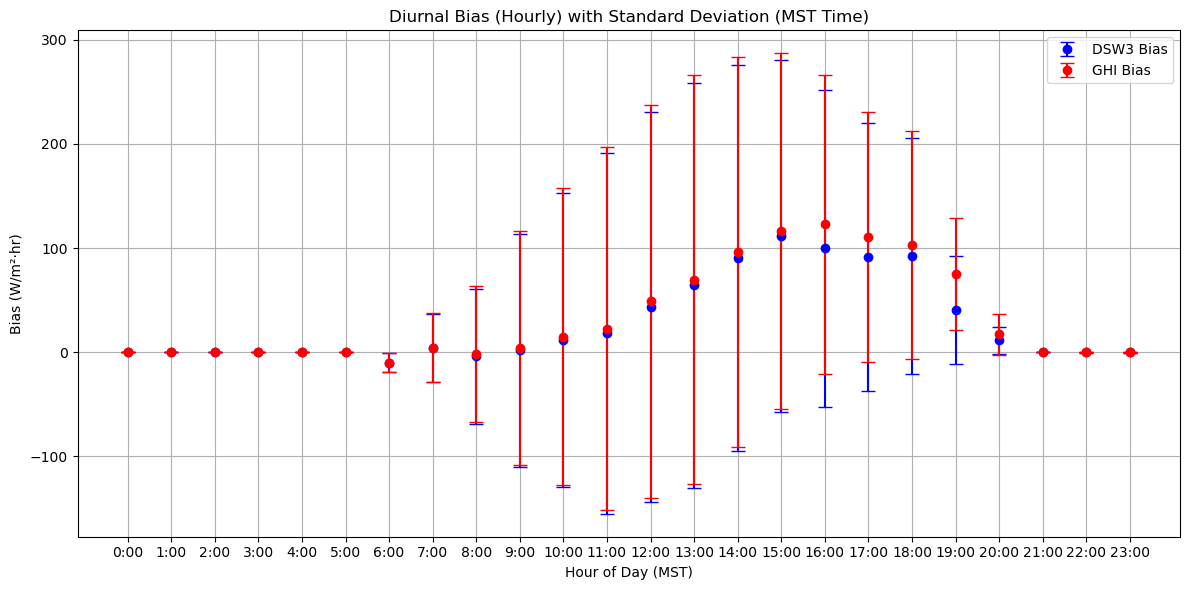

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming data is already filtered and aligned as obs_filtered, dsw3_filtered, ghi_filtered

# Convert index to UTC (if it's in another timezone) and then adjust for MST (UTC-7)
# In this case, we will shift the index by -7 hours to convert from UTC to MST
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]
obs_filtered.index = obs_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_filtered.index = dsw3_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
ghi_filtered.index = ghi_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')

# Calculate diurnal (hourly) bias
hourly_bias = pd.DataFrame({
    'DSW3 Bias': (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).mean(),
    'GHI Bias':  (ghi_filtered - obs_filtered).groupby(ghi_filtered.index.hour).mean(),
})

# Calculate standard deviation for diurnal bias
hourly_std = pd.DataFrame({
    'DSW3 Std': (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).std(),
    'GHI Std':  (ghi_filtered - obs_filtered).groupby(ghi_filtered.index.hour).std(),
})

# Plot the diurnal bias with points and whiskers for standard deviation
plt.figure(figsize=(12, 6))

# Plot DSW3 Bias with Std Dev
plt.errorbar(hourly_bias.index, hourly_bias['DSW3 Bias'], yerr=hourly_std['DSW3 Std'], fmt='o', color='blue', label='DSW3 Bias', capsize=5)

# Plot GHI Bias with Std Dev
plt.errorbar(hourly_bias.index, hourly_bias['GHI Bias'], yerr=hourly_std['GHI Std'], fmt='o', color='red', label='GHI Bias', capsize=5)

# Title and labels
plt.title('Diurnal Bias (Hourly) with Standard Deviation (MST Time)')
plt.xlabel('Hour of Day (MST)')
plt.ylabel('Bias (W/m²·hr)')

# Set x-ticks to show hour ranges for MST time (0-23)
plt.xticks(range(24), labels=[f'{i}:00' for i in range(24)])

# Show legend
plt.legend()

# Grid and layout
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


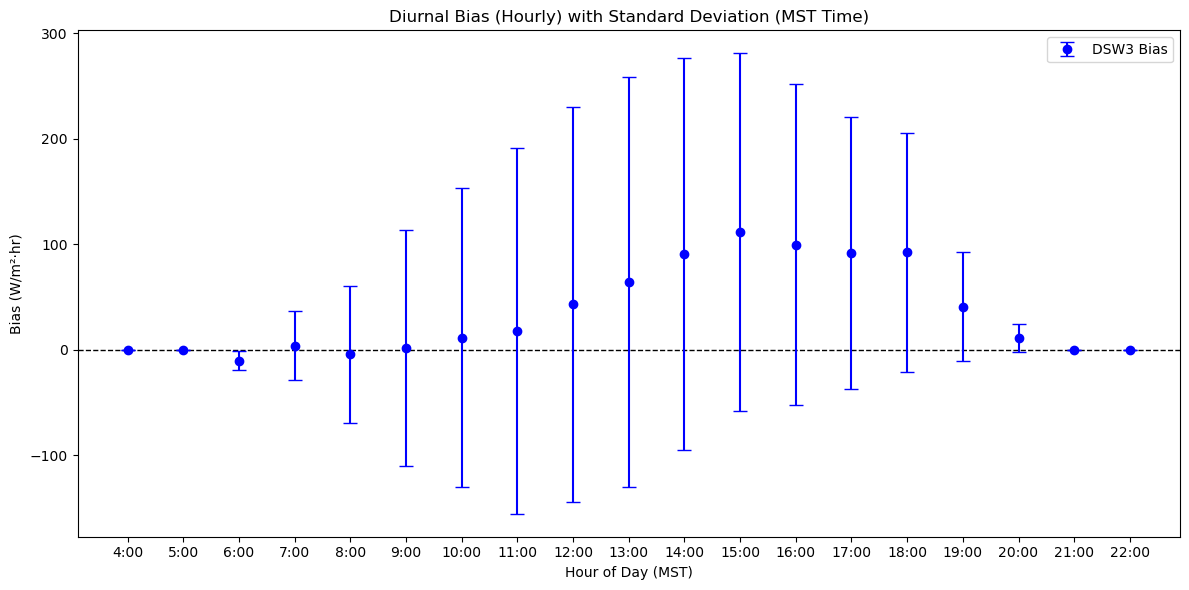

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming data is already filtered and aligned as obs_filtered, dsw3_filtered, ghi_filtered

# Convert index to UTC (if it's in another timezone) and then adjust for MST (UTC-7)
# In this case, we will shift the index by -7 hours to convert from UTC to MST
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]
obs_filtered.index = obs_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_filtered.index = dsw3_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
ghi_filtered.index = ghi_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')

# Calculate diurnal (hourly) bias for DSW3
hourly_bias = (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).mean()

# Calculate standard deviation for diurnal bias
hourly_std = (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).std()

# Only select hours between 4 and 22
hour_range = hourly_bias.loc[4:22]
std_range = hourly_std.loc[4:22]

# Plot the diurnal bias with points and whiskers for standard deviation (only for DSW3)
plt.figure(figsize=(12, 6))

# Plot DSW3 Bias with Std Dev
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.errorbar(hour_range.index, hour_range, yerr=std_range, fmt='o', color='blue', label='DSW3 Bias', capsize=5)

# Title and labels
plt.title('Diurnal Bias (Hourly) with Standard Deviation (MST Time)')
plt.xlabel('Hour of Day (MST)')
plt.ylabel('Bias (W/m²·hr)')

# Set x-ticks to show hour ranges for MST time (4:00 to 22:00)
plt.xticks(range(4, 23), labels=[f'{i}:00' for i in range(4, 23)])

# Show legend
plt.legend()

# Remove grid lines
plt.grid(False)

# Layout
plt.tight_layout()

# Show the plot
plt.show()


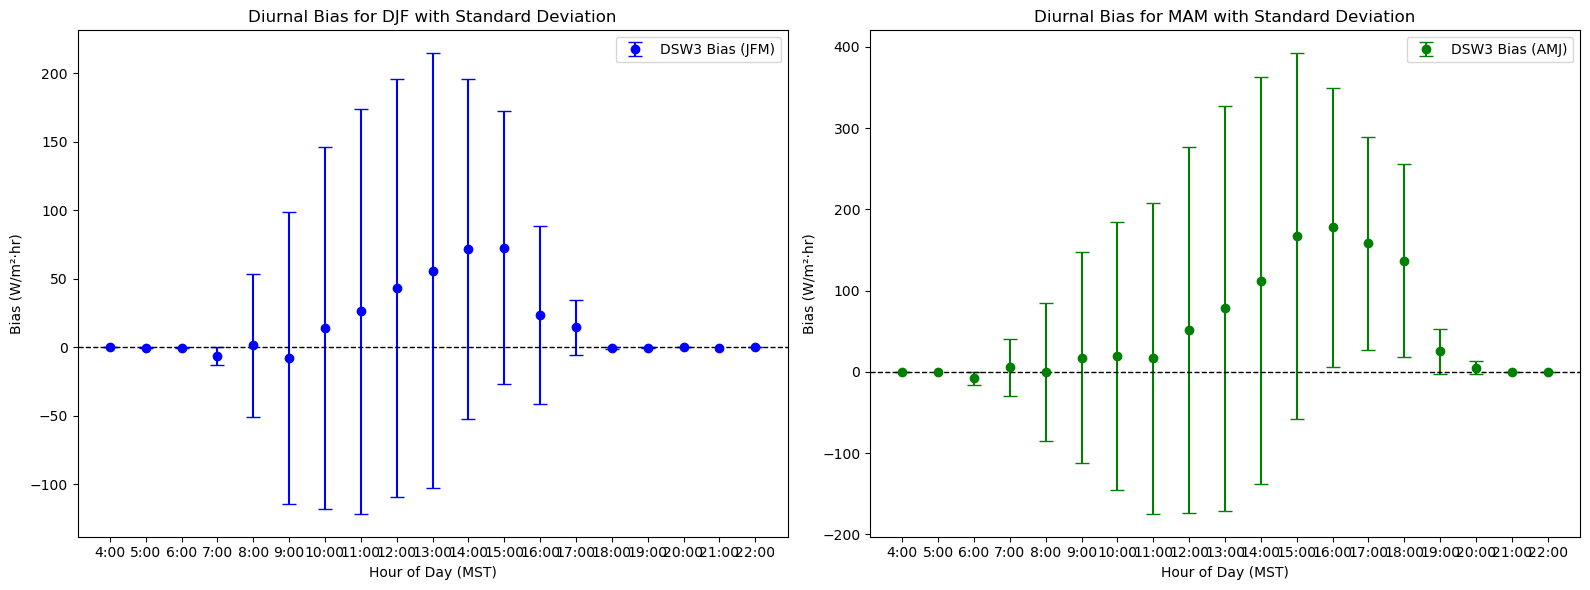

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming data is already filtered and aligned as obs_filtered, dsw3_filtered, ghi_filtered

# Convert index to UTC (if it's in another timezone) and then adjust for MST (UTC-7)
# In this case, we will shift the index by -7 hours to convert from UTC to MST
obs_filtered  = obs_aligned.loc[mask]
dsw3_filtered = dsw3_aligned.loc[mask]
ghi_filtered  = ghi_aligned.loc[mask]
obs_filtered.index = obs_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_filtered.index = dsw3_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')
ghi_filtered.index = ghi_filtered.index.tz_localize('UTC').tz_convert('US/Mountain')

# Calculate diurnal (hourly) bias for DSW3
hourly_bias = (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).mean()

# Calculate standard deviation for diurnal bias
hourly_std = (dsw3_filtered - obs_filtered).groupby(dsw3_filtered.index.hour).std()

# Filter the data for JFM (January, February, March) and AMJ (April, May, June)
jfm_filter = (dsw3_filtered.index.month.isin([12, 1, 2]))
amj_filter = (dsw3_filtered.index.month.isin([3, 4, 5]))

dsw3_jfm_filtered = dsw3_filtered[jfm_filter]
obs_jfm_filtered = obs_filtered[jfm_filter]

dsw3_amj_filtered = dsw3_filtered[amj_filter]
obs_amj_filtered = obs_filtered[amj_filter]

# Calculate diurnal (hourly) bias for DSW3 in JFM and AMJ
hourly_bias_jfm = (dsw3_jfm_filtered - obs_jfm_filtered).groupby(dsw3_jfm_filtered.index.hour).mean()
hourly_std_jfm = (dsw3_jfm_filtered - obs_jfm_filtered).groupby(dsw3_jfm_filtered.index.hour).std()

hourly_bias_amj = (dsw3_amj_filtered - obs_amj_filtered).groupby(dsw3_amj_filtered.index.hour).mean()
hourly_std_amj = (dsw3_amj_filtered - obs_amj_filtered).groupby(dsw3_amj_filtered.index.hour).std()

# Only select hours between 4 and 22 for both JFM and AMJ
hour_range_jfm = hourly_bias_jfm.loc[4:22]
std_range_jfm = hourly_std_jfm.loc[4:22]

hour_range_amj = hourly_bias_amj.loc[4:22]
std_range_amj = hourly_std_amj.loc[4:22]

# Plot the diurnal bias for JFM and AMJ in side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot JFM (January, February, March)
axs[0].errorbar(hour_range_jfm.index, hour_range_jfm, yerr=std_range_jfm, fmt='o', color='blue', label='DSW3 Bias (JFM)', capsize=5)
axs[0].axhline(0, color='black', linestyle='--', linewidth=1)  # Horizontal line at 0
axs[0].set_title('Diurnal Bias for DJF with Standard Deviation')
axs[0].set_xlabel('Hour of Day (MST)')
axs[0].set_ylabel('Bias (W/m²·hr)')
axs[0].set_xticks(range(4, 23))
axs[0].set_xticklabels([f'{i}:00' for i in range(4, 23)])
axs[0].legend()
axs[0].grid(False)  # Remove grid lines

# Plot AMJ (April, May, June)
axs[1].errorbar(hour_range_amj.index, hour_range_amj, yerr=std_range_amj, fmt='o', color='green', label='DSW3 Bias (AMJ)', capsize=5)
axs[1].axhline(0, color='black', linestyle='--', linewidth=1)  # Horizontal line at 0
axs[1].set_title('Diurnal Bias for MAM with Standard Deviation')
axs[1].set_xlabel('Hour of Day (MST)')
axs[1].set_ylabel('Bias (W/m²·hr)')
axs[1].set_xticks(range(4, 23))
axs[1].set_xticklabels([f'{i}:00' for i in range(4, 23)])
axs[1].legend()
axs[1].grid(False)  # Remove grid lines

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


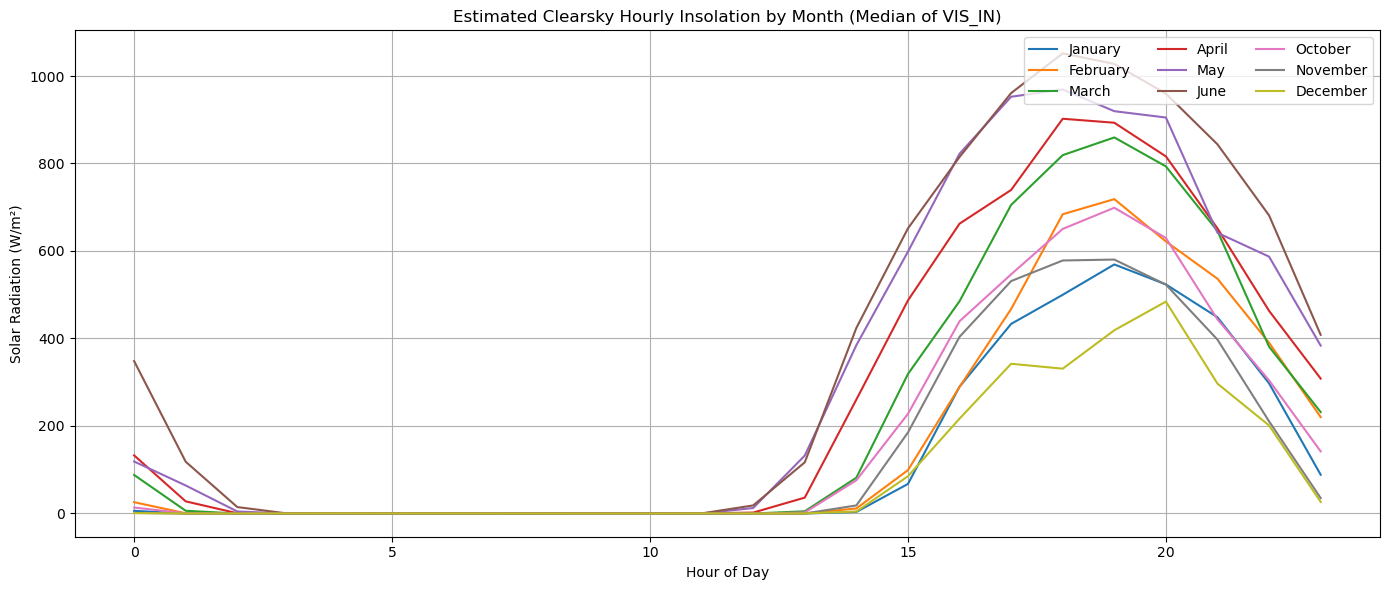

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the index is a datetime
irwin_pyra_hourly_wy2022.index = pd.to_datetime(irwin_pyra_hourly_wy2022.index)

# Extract hour and month from the datetime index
irwin_pyra_hourly_wy2022['hour'] = irwin_pyra_hourly_wy2022.index.hour
irwin_pyra_hourly_wy2022['month'] = irwin_pyra_hourly_wy2022.index.month

# Group by month and hour, then calculate the median and mean VIS_IN
clearsky_median = irwin_pyra_hourly_wy2022.groupby(['month', 'hour'])['VIS_IN'].median().unstack()
clearsky_mean   = irwin_pyra_hourly_wy2022.groupby(['month', 'hour'])['VIS_IN'].mean().unstack()

# Plotting the "clearsky" (median) insolation by hour for each month
plt.figure(figsize=(14, 6))
for month in range(1, 13):
    if month in clearsky_median.index:
        plt.plot(clearsky_median.columns, clearsky_median.loc[month], label=pd.to_datetime(f'{month}', format='%m').strftime('%B'))

plt.title('Estimated Clearsky Hourly Insolation by Month (Median of VIS_IN)')
plt.xlabel('Hour of Day')
plt.ylabel('Solar Radiation (W/m²)')
plt.legend(loc='upper right', ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()


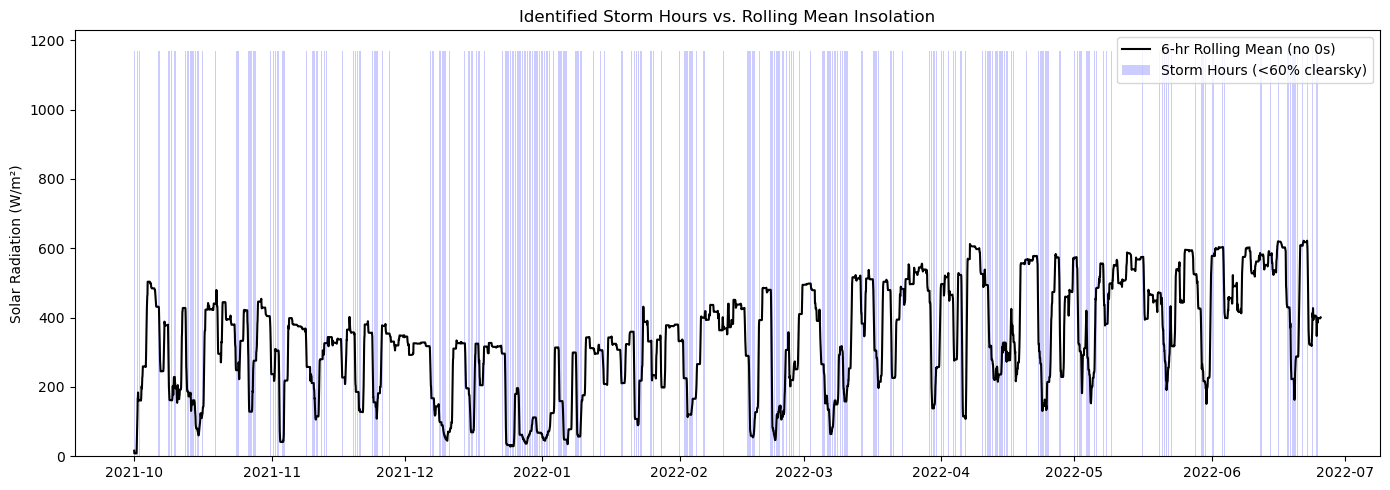

In [151]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime index and drop missing values
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)

# Extract month and hour for mapping to median clearsky
obs['month'] = obs.index.month
obs['hour'] = obs.index.hour

# Calculate clearsky (median) by month and hour
clearsky_median = obs.groupby(['month', 'hour'])['VIS_IN'].median().unstack()

# Map the clearsky value to each row in the observed data
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour']], axis=1)

# Compute ratio and flag storm hours (<60% of clearsky)
obs['ratio'] = obs['VIS_IN'] / obs['clearsky_VIS_IN']
obs['storm_hour'] = obs['ratio'] < 0.75

# Calculate 6-hour rolling mean (excluding 0s)
win = 24
rolling_mean = obs['VIS_IN'].where(obs['VIS_IN'] > 0).rolling(window=win, min_periods=1).mean()

# Plot storm hours and rolling mean
plt.figure(figsize=(14, 5))
plt.bar(obs.index, obs['storm_hour']*obs['VIS_IN'].max(), width=0.03, alpha=0.2, color='blue', label='Storm Hours (<60% clearsky)')
plt.plot(rolling_mean.index, rolling_mean, color='black', linewidth=1.5, label='6-hr Rolling Mean (no 0s)')
plt.ylabel('Solar Radiation (W/m²)')
plt.title('Identified Storm Hours vs. Rolling Mean Insolation')
plt.legend()
plt.tight_layout()
plt.show()


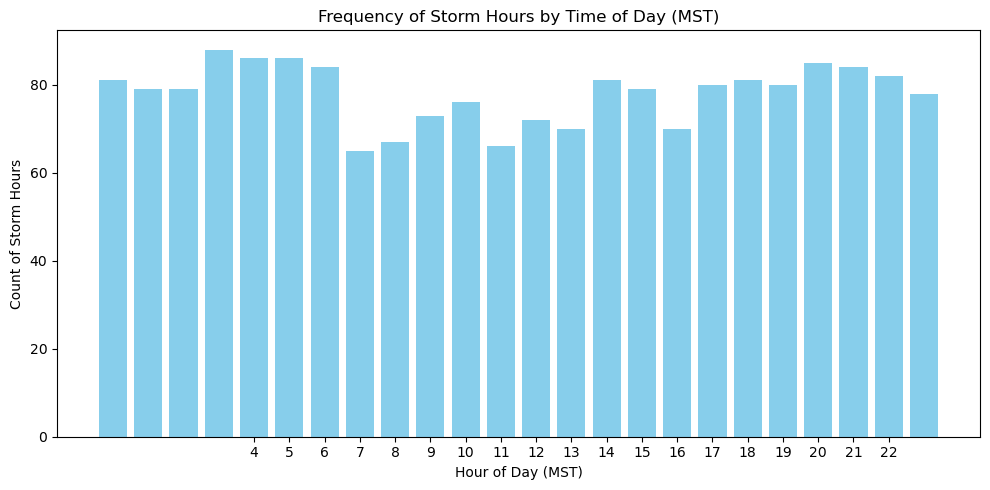

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy and ensure datetime
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)

# Convert to MST (UTC-7)
obs.index = obs.index.tz_localize('UTC').tz_convert('US/Mountain')
obs['hour_mst'] = obs.index.hour
obs['month'] = obs.index.month

# Compute median clearsky values by hour/month
clearsky_median = obs.groupby(['month', 'hour_mst'])['VIS_IN'].median().unstack()
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour_mst']], axis=1)

# Identify storm hours
obs['ratio'] = obs['VIS_IN'] / obs['clearsky_VIS_IN']
obs['storm_hour'] = obs['ratio'] < 0.6

# Count storm hours by hour of day
storm_hour_counts = obs[obs['storm_hour']].groupby('hour_mst').size()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(storm_hour_counts.index, storm_hour_counts.values, color='skyblue')
plt.xticks(range(4, 23))
plt.xlabel('Hour of Day (MST)')
plt.ylabel('Count of Storm Hours')
plt.title('Frequency of Storm Hours by Time of Day (MST)')
plt.tight_layout()
plt.show()


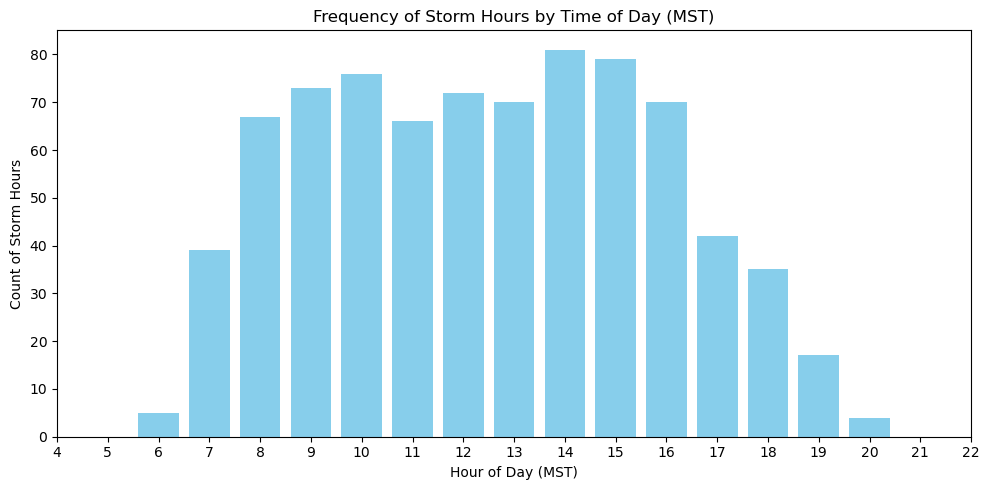

In [153]:
# Only consider hours where clearsky is greater than a threshold (e.g., >10 W/m²)
obs['is_daylight'] = obs['clearsky_VIS_IN'] > 10

# Only compute ratio where daylight is present
obs_day = obs[obs['is_daylight']].copy()
obs_day['ratio'] = obs_day['VIS_IN'] / obs_day['clearsky_VIS_IN']
obs_day['storm_hour'] = obs_day['ratio'] < 0.6

# Count storm hours by time of day (MST)
storm_hour_counts = obs_day[obs_day['storm_hour']].groupby('hour_mst').size()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(storm_hour_counts.index, storm_hour_counts.values, color='skyblue')
plt.xticks(range(4, 23))  # Typical daylight hours
plt.xlabel('Hour of Day (MST)')
plt.ylabel('Count of Storm Hours')
plt.title('Frequency of Storm Hours by Time of Day (MST)')
plt.tight_layout()
plt.show()


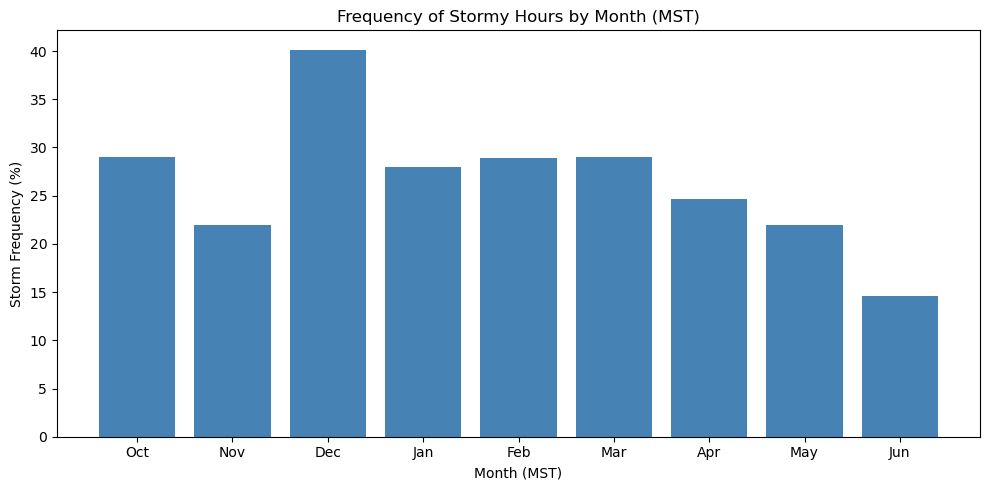

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime and convert to MST
obs = irwin_pyra_hourly_wy2022[['VIS_IN']].copy()
obs.index = pd.to_datetime(obs.index)
obs.dropna(subset=['VIS_IN'], inplace=True)
obs.index = obs.index.tz_localize('UTC').tz_convert('US/Mountain')

# Extract month and hour
obs['hour_mst'] = obs.index.hour
obs['month'] = obs.index.month

# Median clearsky values (per hour per month)
clearsky_median = obs.groupby(['month', 'hour_mst'])['VIS_IN'].median().unstack()

# Map clearsky expected value to each row
obs['clearsky_VIS_IN'] = obs.apply(lambda row: clearsky_median.loc[row['month'], row['hour_mst']], axis=1)

# Filter to daytime hours (clearsky VIS_IN > 10)
obs_daylight = obs[obs['clearsky_VIS_IN'] > 10].copy()

# Storm detection
obs_daylight['ratio'] = obs_daylight['VIS_IN'] / obs_daylight['clearsky_VIS_IN']
obs_daylight['storm_hour'] = obs_daylight['ratio'] < 0.6

# Count storm hours and total daylight hours per month
storm_counts = obs_daylight.groupby('month')['storm_hour'].sum()
daylight_counts = obs_daylight.groupby('month').size()
storm_freq = (storm_counts / daylight_counts) * 100

# Limit to water year: Oct (10) to Jun (6)
months_ordered = [10, 11, 12, 1, 2, 3, 4, 5, 6]
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
storm_freq = storm_freq.reindex(months_ordered)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(month_names, storm_freq.values, color='steelblue')
plt.ylabel('Storm Frequency (%)')
plt.xlabel('Month (MST)')
plt.title('Frequency of Stormy Hours by Month (MST)')
plt.tight_layout()
plt.show()


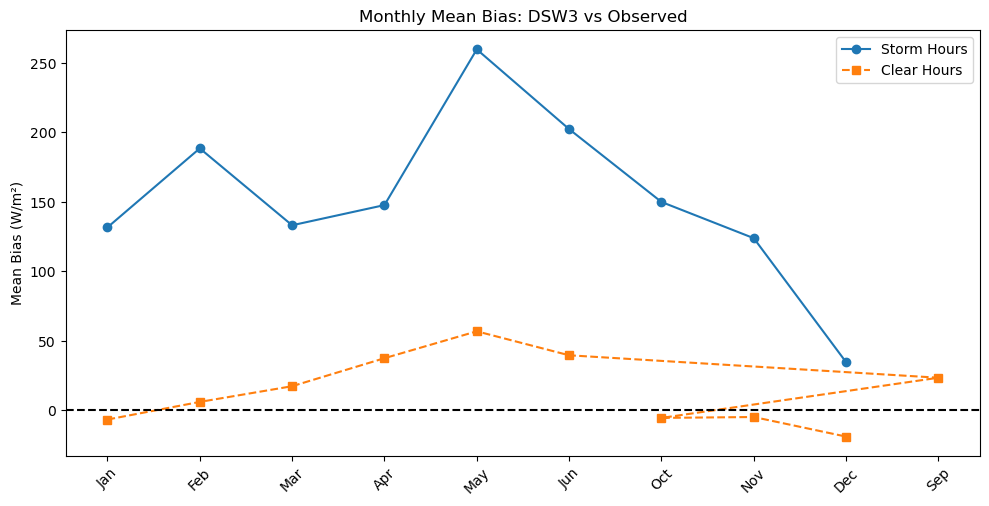

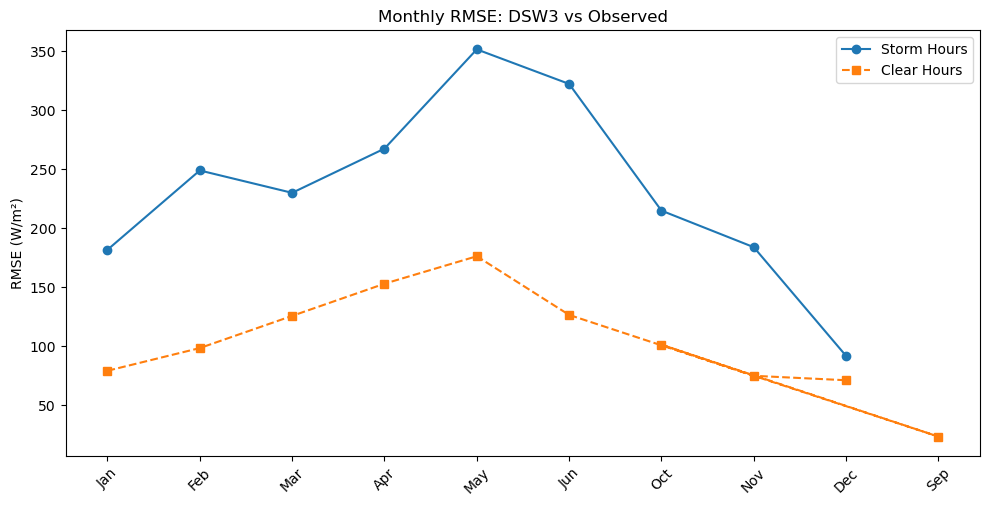

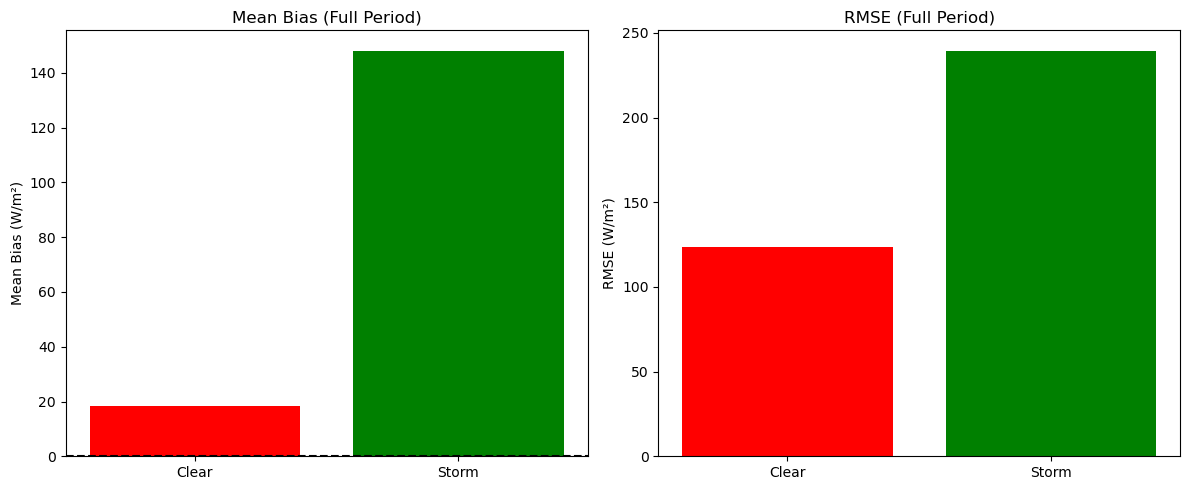

In [149]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# # Align model to obs_daylight
# dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
# dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
# bias = dsw3_aligned - obs_daylight['VIS_IN']

# # Attach bias and storm info
# analysis_df = pd.DataFrame({
#     'bias': bias,
#     'storm': obs_daylight['storm_hour'],
#     'month': obs_daylight['month'],
#     'hour': obs_daylight['hour_mst']
# })

# # Define RMSE function
# def rmse(x):
#     return np.sqrt(np.mean(x**2))

# # Group by month and storm status
# monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', rmse]).reset_index()

# # Map the month numbers to month names
# month_map = {
#     1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
#     7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
# }
# monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# # Sort the DataFrame by month in chronological order
# monthly_stats = monthly_stats.sort_values(by='month')

# # Assign 'Condition' as 'Storm' or 'Clear'
# monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# # Plot Mean Bias
# plt.figure(figsize=(10, 5))
# for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
#     subset = monthly_stats[monthly_stats['Condition'] == cond]
#     plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
# plt.axhline(0, color='black', linestyle='--')
# plt.ylabel('Mean Bias (W/m²)')
# plt.title('Monthly Mean Bias: DSW3 vs Observed')
# plt.legend()
# plt.tight_layout()
# plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# plt.show()

# # Plot RMSE
# plt.figure(figsize=(10, 5))
# for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
#     subset = monthly_stats[monthly_stats['Condition'] == cond]
#     plt.plot(subset['Month'], subset['rmse'], style, label=f'{cond} Hours')
# plt.ylabel('RMSE (W/m²)')
# plt.title('Monthly RMSE: DSW3 vs Observed')
# plt.legend()
# plt.tight_layout()
# plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# plt.show()

# # Overall stats for storm vs clear
# overall_stats = analysis_df.groupby('storm')['bias'].agg(['mean', rmse]).reset_index()
# overall_stats['Condition'] = np.where(overall_stats['storm'], 'Storm', 'Clear')

# # Bar plot for full-period mean bias and RMSE
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# axes[0].bar(overall_stats['Condition'], overall_stats['mean'], color=['red', 'green'])
# axes[0].set_title('Mean Bias (Full Period)')
# axes[0].set_ylabel('Mean Bias (W/m²)')
# axes[0].axhline(0, color='black', linestyle='--')

# axes[1].bar(overall_stats['Condition'], overall_stats['rmse'], color=['red', 'green'])
# axes[1].set_title('RMSE (Full Period)')
# axes[1].set_ylabel('RMSE (W/m²)')

# plt.tight_layout()
# plt.show()


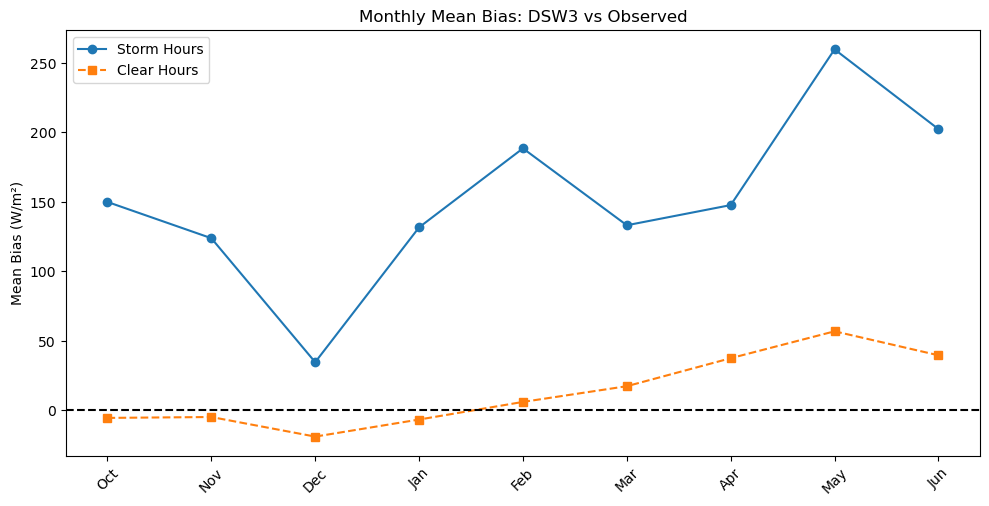

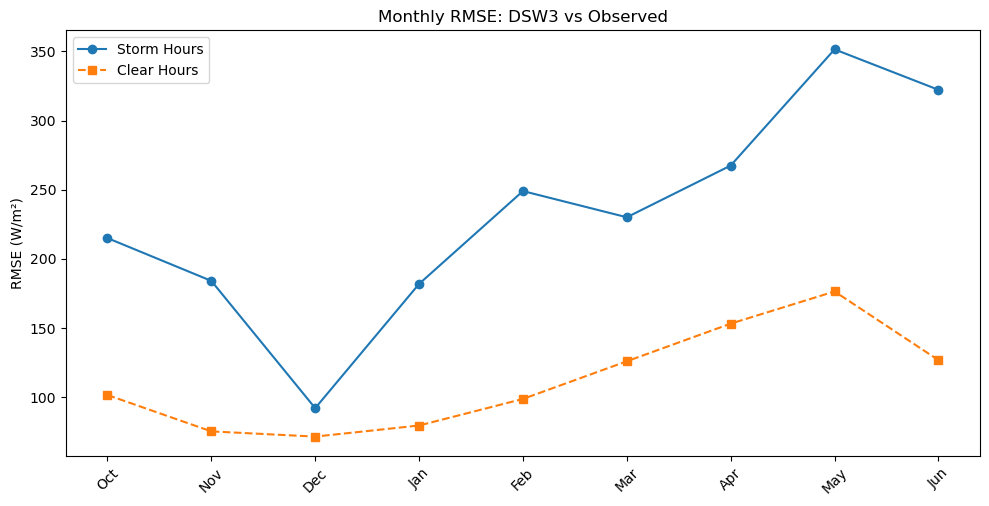

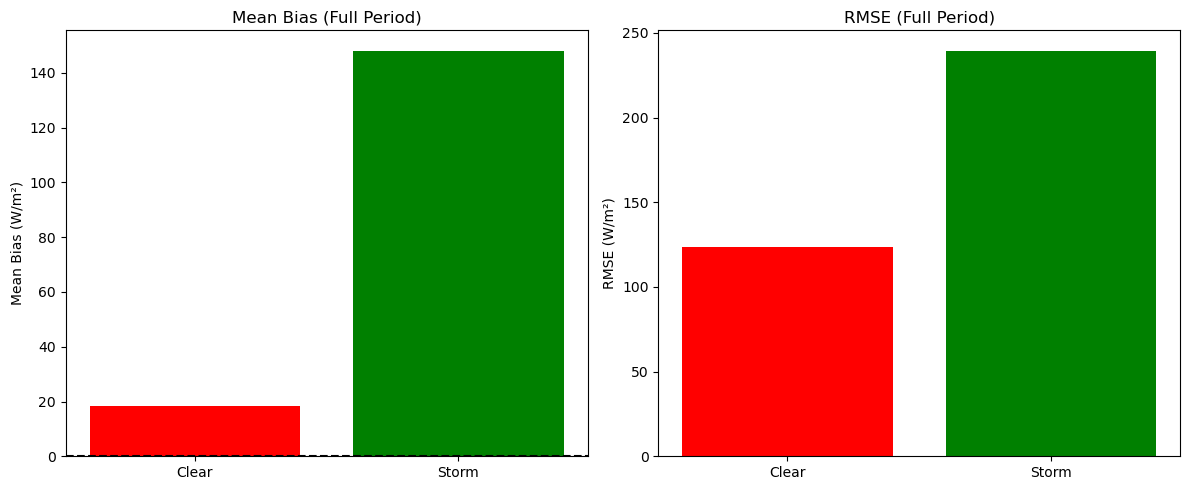

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# Align model to obs_daylight
dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
bias = dsw3_aligned - obs_daylight['VIS_IN']

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)')
plt.title('Monthly Mean Bias: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Plot RMSE
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['rmse'], style, label=f'{cond} Hours')
plt.ylabel('RMSE (W/m²)')
plt.title('Monthly RMSE: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Overall stats for storm vs clear
overall_stats = analysis_df.groupby('storm')['bias'].agg(['mean', rmse]).reset_index()
overall_stats['Condition'] = np.where(overall_stats['storm'], 'Storm', 'Clear')

# Bar plot for full-period mean bias and RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(overall_stats['Condition'], overall_stats['mean'], color=['red', 'green'])
axes[0].set_title('Mean Bias (Full Period)')
axes[0].set_ylabel('Mean Bias (W/m²)')
axes[0].axhline(0, color='black', linestyle='--')

axes[1].bar(overall_stats['Condition'], overall_stats['rmse'], color=['red', 'green'])
axes[1].set_title('RMSE (Full Period)')
axes[1].set_ylabel('RMSE (W/m²)')

plt.tight_layout()
plt.show()


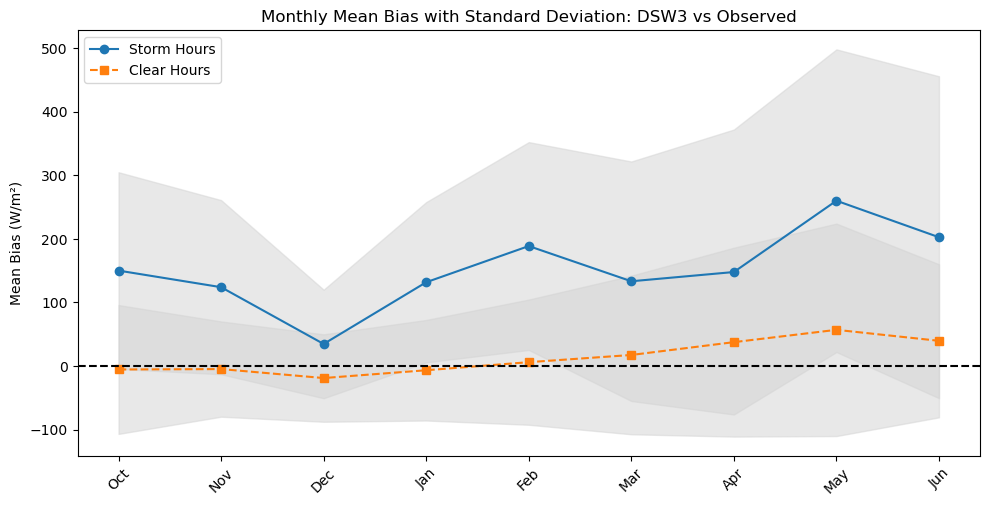

In [156]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# Align model to obs_daylight
dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
bias = dsw3_aligned - obs_daylight['VIS_IN']

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
    # Add standard deviation as shaded area around the mean
    plt.fill_between(subset['Month'], subset['mean'] - subset['std'], subset['mean'] + subset['std'], 
                     color='lightgrey', alpha=0.5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)')
plt.title('Monthly Mean Bias with Standard Deviation: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


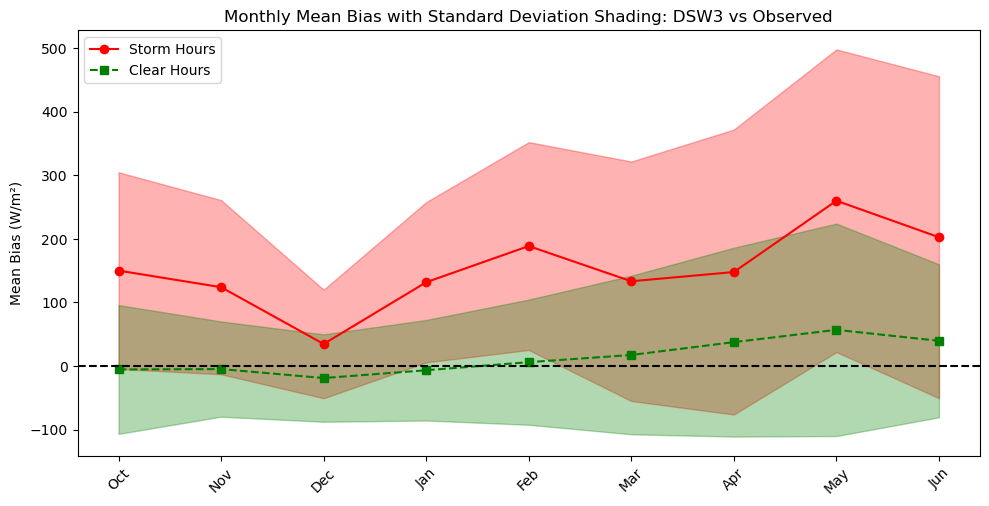

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# Align model to obs_daylight
dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
bias = dsw3_aligned - obs_daylight['VIS_IN']

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation Shading
plt.figure(figsize=(10, 5))
for cond, style, color in zip(['Storm', 'Clear'], ['o-', 's--'], ['red', 'green']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    # Add shading for standard deviation
    plt.fill_between(subset['Month'], subset['mean'] - subset['std'], subset['mean'] + subset['std'],
                     color=color, alpha=0.3)  # 30% transparency for shading
    # Plot the mean bias line
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours', color=color)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)')
plt.title('Monthly Mean Bias with Standard Deviation Shading: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()



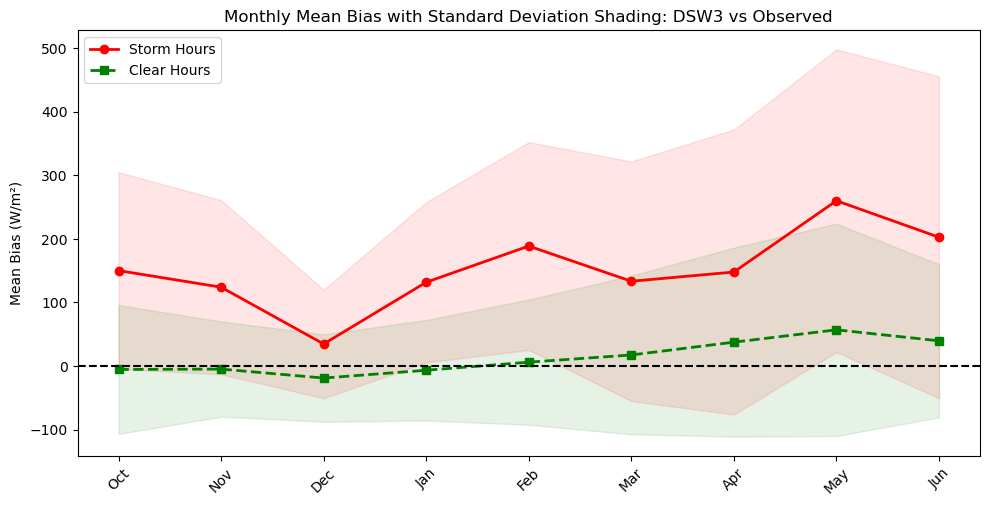

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# Align model to obs_daylight
dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
bias = dsw3_aligned - obs_daylight['VIS_IN']

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation Shading
plt.figure(figsize=(10, 5))

# Plot the shaded region first (with more transparency)
for cond, style, color in zip(['Storm', 'Clear'], ['o-', 's--'], ['red', 'green']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    # Add shading for standard deviation with more transparency
    plt.fill_between(subset['Month'], subset['mean'] - subset['std'], subset['mean'] + subset['std'],
                     color=color, alpha=0.1)  # Reduced transparency for the shaded area

# Plot the mean bias lines on top (with less transparency for contrast)
for cond, style, color in zip(['Storm', 'Clear'], ['o-', 's--'], ['red', 'green']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours', color=color, linewidth=2)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)')
plt.title('Monthly Mean Bias with Standard Deviation Shading: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


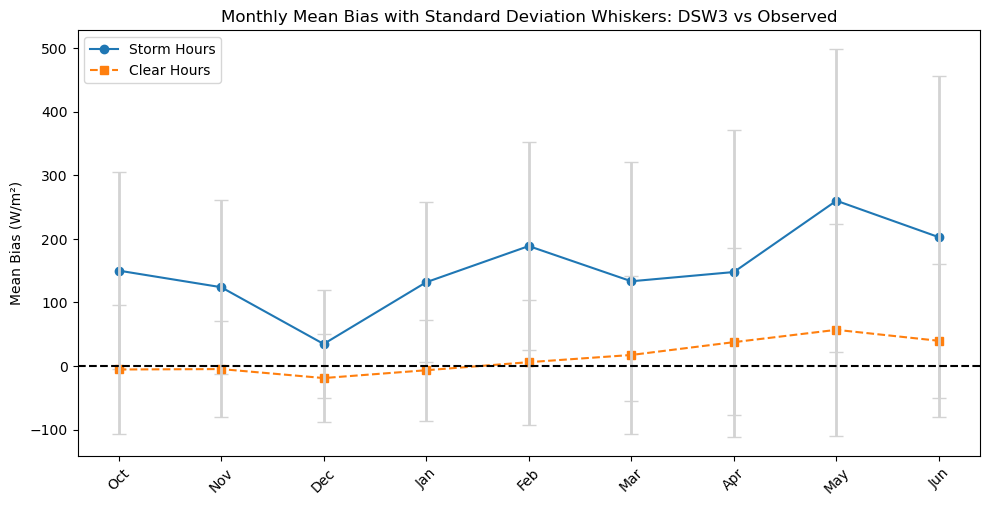

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume obs_daylight and dsw3_valid (aligned, cleaned) already exist
# Align model to obs_daylight
dsw3_mst = dsw3.tz_localize('UTC').tz_convert('US/Mountain')
dsw3_aligned = dsw3_mst.loc[obs_daylight.index]
bias = dsw3_aligned - obs_daylight['VIS_IN']

# Attach bias and storm info
analysis_df = pd.DataFrame({
    'bias': bias,
    'storm': obs_daylight['storm_hour'],
    'month': obs_daylight['month'],
    'hour': obs_daylight['hour_mst']
})

# Define RMSE function
def rmse(x):
    return np.sqrt(np.mean(x**2))

# Group by month and storm status
monthly_stats = analysis_df.groupby(['month', 'storm'])['bias'].agg(['mean', 'std', rmse]).reset_index()

# Map the month numbers to month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_stats['Month'] = monthly_stats['month'].map(month_map)

# Filter out September
monthly_stats = monthly_stats[monthly_stats['month'] != 9]

# Manually reorder months to go from Oct to Jun
month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
monthly_stats['Month'] = pd.Categorical(monthly_stats['Month'], categories=month_order, ordered=True)

# Sort the DataFrame by the month order
monthly_stats = monthly_stats.sort_values(by='Month')

# Assign 'Condition' as 'Storm' or 'Clear'
monthly_stats['Condition'] = np.where(monthly_stats['storm'], 'Storm', 'Clear')

# Plot Mean Bias with Standard Deviation as Whiskers
plt.figure(figsize=(10, 5))
for cond, style in zip(['Storm', 'Clear'], ['o-', 's--']):
    subset = monthly_stats[monthly_stats['Condition'] == cond]
    # Plot the mean bias
    plt.plot(subset['Month'], subset['mean'], style, label=f'{cond} Hours')
    # Add standard deviation as whiskers (error bars)
    plt.errorbar(subset['Month'], subset['mean'], yerr=subset['std'], fmt='none', 
                 ecolor='lightgrey', elinewidth=2, capsize=5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Mean Bias (W/m²)')
plt.title('Monthly Mean Bias with Standard Deviation Whiskers: DSW3 vs Observed')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


## Weekly checks

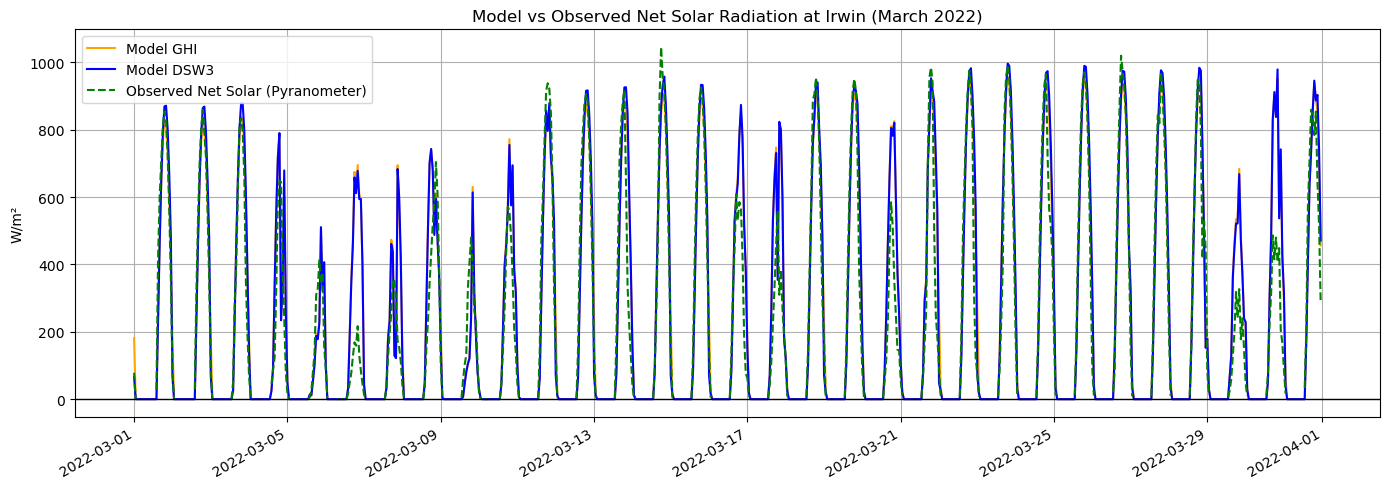

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
irwin_pyra.index = pd.to_datetime(irwin_pyra.index)

# Resample to hourly data
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()

# Subset to Water Year 2022
irwin_pyra_hourly_wy2022 = irwin_pyra_hourly.loc['2021-10-01':'2022-09-30']

# Filter for March only
irwin_pyra_march = irwin_pyra_hourly_wy2022[irwin_pyra_hourly_wy2022.index.month == 3]

# Filter model data to March (assuming xarray format)
march_mask = (dsw1_daily['time.month'] == 3) & (dsw1_daily['time.year'] == 2022)
dsw1_march = dsw1_daily.sel(time=march_mask)
dsw3_march = dsw3_daily.sel(time=march_mask)
ghi_march  = ghi_daily.sel(time=march_mask)

# Get March observational net solar
obs_net_solar_march = irwin_pyra_march['VIS_IN']
obs_net_solar_march = obs_net_solar_march.where(obs_net_solar_march > 0)  # filter negatives

# Plotting
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ghi_march.time, ghi_march, label='Model GHI', color='orange')
# ax.plot(dsw1_march.time, dsw1_march, label='Model DSW1', color='blue')
ax.plot(dsw3_march.time, dsw3_march, label='Model DSW3', color='blue')
ax.plot(obs_net_solar_march.index, obs_net_solar_march, label='Observed Net Solar (Pyranometer)', color='green', linestyle='--')

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Model vs Observed Net Solar Radiation at Irwin (March 2022)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [31]:
import pandas as pd

idf = pd.read_csv('/uufs/chpc.utah.edu/common/home/u1037042/Documents/isnobal_data/irwin/Irwin_USGS.csv')

# Load the CSV (adjust the filename as needed)
# idf = pd.read_csv('idf.csv')
# Select only the required columns
idf = idf[['datetime', '307700_72175', '307704_72186']]

# Rename the columns for convenience
idf = idf.rename(columns={
    '307700_72175': 'Longwave_down',
    '307704_72186': 'Shortwave_down'
})

# Cap Shortwave_down values between 0 and 1300 W/m²
idf['Shortwave_down'] = idf['Shortwave_down'].clip(lower=0, upper=1300)

# Convert 'datetime' to pandas datetime format
idf['datetime'] = pd.to_datetime(idf['datetime'], format='%m/%d/%y %H:%M')

# Convert timezone from the 'tz_cd' column (MST to UTC)
# Assuming 'MST' is the timezone, you can change it to your required timezone (e.g., UTC)
idf['datetime'] = idf['datetime'].dt.tz_localize('MST').dt.tz_convert('UTC')
idf

,datetime,Longwave_down,Shortwave_down
0,2022-02-01 07:00:00+00:00,207.0,0.00
1,2022-02-01 08:00:00+00:00,206.0,0.00
2,2022-02-01 09:00:00+00:00,205.0,0.00
3,2022-02-01 10:00:00+00:00,206.0,0.00
4,2022-02-01 11:00:00+00:00,209.0,0.00
...,...,...,...
1434,2022-04-02 02:00:00+00:00,242.0,56.40
1435,2022-04-02 03:00:00+00:00,229.0,5.86
1436,2022-04-02 04:00:00+00:00,223.0,0.00
1437,2022-04-02 05:00:00+00:00,221.0,0.00


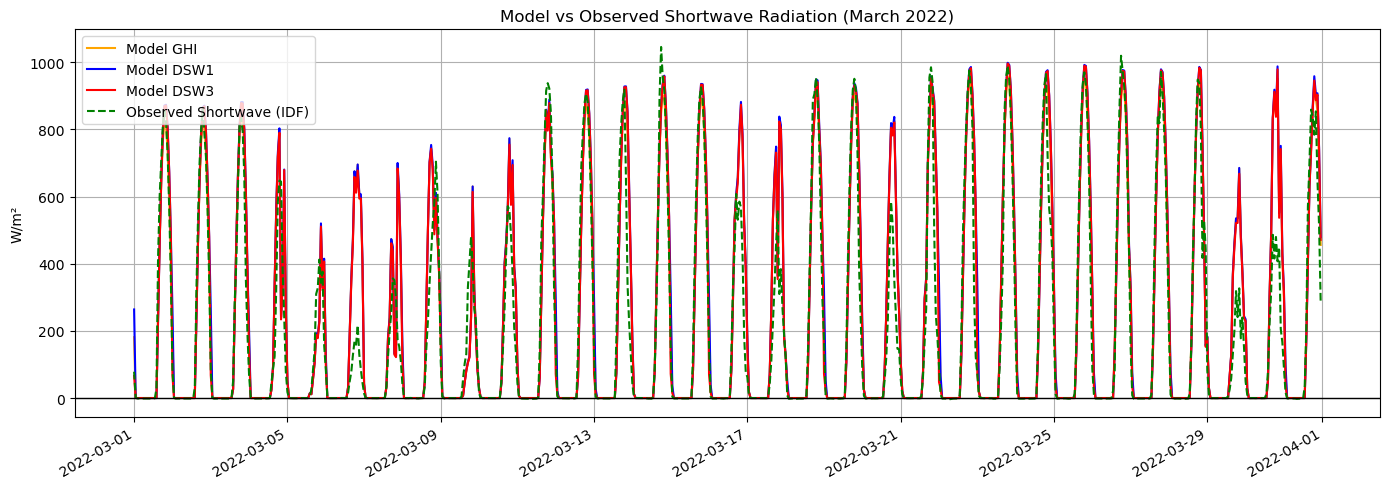

In [28]:
# Resample to hourly if needed (optional, depending on model resolution)
# idf_hourly = idf.set_index('datetime').resample('1h').mean()

# Filter to March 2022
# idf_march = idf_hourly.loc['2022-03-01':'2022-03-31']
idf_march = irwin_pyra_hourly.loc['2022-03-01':'2022-03-31']

# === 2. Prepare Model Data ===
# Rolling (1 means hourly in your case; no smoothing)
win = 1
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily  = irwin_ghi.rolling(time=win, center=True).mean()

# Select March 2022 from model data
march_mask = (dsw1_daily['time.month'] == 3) & (dsw1_daily['time.year'] == 2022)
dsw1_march = dsw1_daily.sel(time=march_mask)
dsw3_march = dsw3_daily.sel(time=march_mask)
ghi_march  = ghi_daily.sel(time=march_mask)


# === 3. Plot Comparison ===
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(ghi_march.time, ghi_march, label='Model GHI', color='orange')
ax.plot(dsw1_march.time, dsw1_march, label='Model DSW1', color='blue')
ax.plot(dsw3_march.time, dsw3_march, label='Model DSW3', color='red')

# Plot station observation
ax.plot(idf_march.index, idf_march['VIS_IN'], label='Observed Shortwave (IDF)', color='green', linestyle='--')

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Model vs Observed Shortwave Radiation (March 2022)')
ax.set_ylabel('W/m²')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd

# Load your CSV (if needed)
# idf = pd.read_csv('your_file.csv')
idf = pd.read_csv('/uufs/chpc.utah.edu/common/home/u1037042/Documents/isnobal_data/irwin/Irwin_USGS.csv')

# Keep only relevant columns
idf = idf[['datetime', 'tz_cd', '307700_72175', '307704_72186']]

# Rename for convenience
idf = idf.rename(columns={
    '307700_72175': 'Longwave_down',
    '307704_72186': 'Shortwave_down'
})

# Cap shortwave values
idf['Shortwave_down'] = idf['Shortwave_down'].clip(lower=0, upper=1300)

# Parse datetime
idf['datetime'] = pd.to_datetime(idf['datetime'], format='%m/%d/%y %H:%M')

# Localize to America/Denver, which handles both MST and MDT correctly
idf['datetime'] = idf['datetime'].dt.tz_localize('America/Denver', ambiguous='NaT')

# Convert to UTC
idf['datetime'] = idf['datetime'].dt.tz_convert('UTC')

# Resample to hourly average
idf_hourly = idf.set_index('datetime')[['Longwave_down', 'Shortwave_down']].resample('1h').mean()

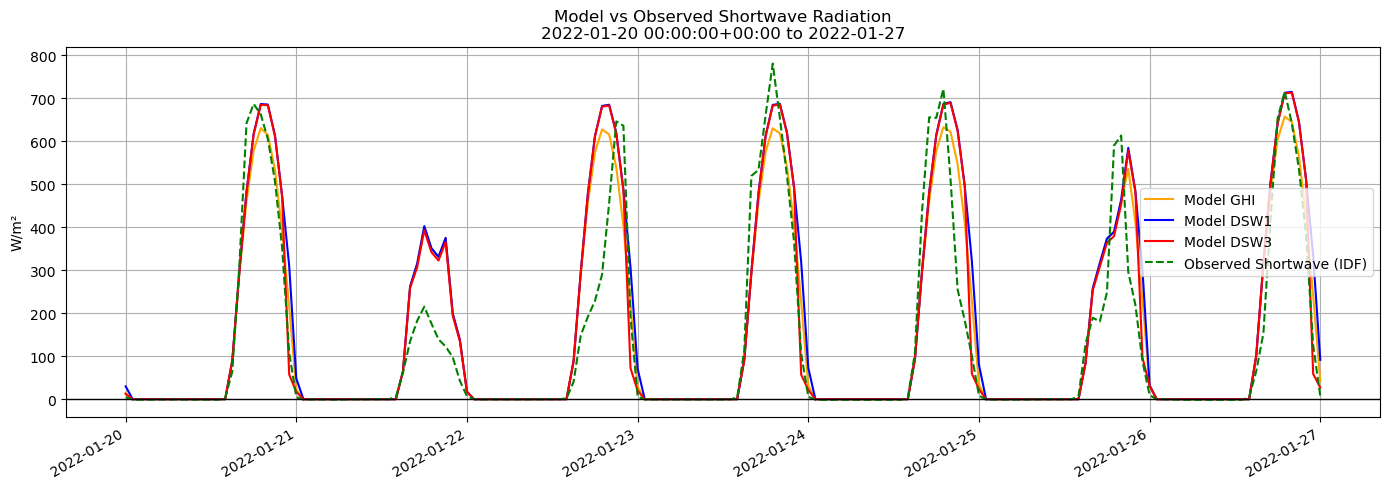

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

# === 1. Set date range inputs ===
start_date = pd.to_datetime('2022-01-20').tz_localize('UTC')
num_days = 7
end_date = start_date + timedelta(days=num_days)

# Use tz-naive copies for slicing xarray model data
start_naive = start_date.tz_convert(None)
end_naive = end_date.tz_convert(None)



# Subset by input date range
# idf_subset = idf_hourly.loc[start_date:end_date]
idf_subset = irwin_pyra_hourly.loc[start_naive:end_naive]



# === 3. Prepare Model Data ===
win = 1  # no smoothing
dsw1_rolling = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_rolling = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_rolling  = irwin_ghi.rolling(time=win, center=True).mean()

# Subset model data using tz-naive timestamps
dsw1_subset = dsw1_rolling.sel(time=slice(start_naive, end_naive))
dsw3_subset = dsw3_rolling.sel(time=slice(start_naive, end_naive))
ghi_subset  = ghi_rolling.sel(time=slice(start_naive, end_naive))



# === 4. Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(ghi_subset.time, ghi_subset, label='Model GHI', color='orange')
ax.plot(dsw1_subset.time, dsw1_subset, label='Model DSW1', color='blue')
ax.plot(dsw3_subset.time, dsw3_subset, label='Model DSW3', color='red')

# Plot station observation
ax.plot(idf_subset.index, idf_subset['VIS_IN'], label='Observed Shortwave (IDF)', color='green', linestyle='--')

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'Model vs Observed Shortwave Radiation\n{start_date} to {end_date.date()}')
ax.set_ylabel('W/m²')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Notes: 

## SAIL comparison!

In [ ]:
# INSPECT SAIL DATA!
import os
# Directory containing the .cdf files
directory = "/uufs/chpc.utah.edu/common/home/skiles-group1/arobledano_test/erw_50m/sebs_SAIL/*.cdf"
ds_sail_list = [np.squeeze(xr.open_dataset(nc)) for nc in sorted(glob.glob(directory))]
ds_sail = xr.concat(ds_sail_list, dim='time')

## Investigate K

In [ ]:
# Use Dask-aware xarray reductions
k = irwin_k

k_stats = {
    'min': k.min().compute().item(),
    'max': k.max().compute().item(),
    'mean': k.mean().compute().item(),
    'median': k.median().compute().item(),
    'std': k.std().compute().item(),
    '25th percentile': k.quantile(0.25).compute().item(),
    '75th percentile': k.quantile(0.75).compute().item(),
    'count (non-NaN)': k.count().compute().item(),
    'NaN count': k.size - k.count().compute().item()
}

# Print nicely
print("Global Statistics for k:")
for key, val in k_stats.items():
    print(f"{key:>18}: {val:.4f}")




In [ ]:
import dask.array as da
import numpy as np
import matplotlib.pyplot as plt

# Assume HRRR_solar is your xarray dataset
# Get the 'k' variable (using Dask array)
k_data = HRRR_solar['k']

# Calculate the mean of 'k' across the time axis (axis 0)
# This will result in a (y, x) array of the mean values
mean_k = k_data.mean(axis=0).compute()  # .compute() triggers the actual computation

# Plot the mean 'k' value (time-averaged) as an image
plt.figure(figsize=(10, 6))
plt.imshow(mean_k, cmap='viridis', origin='lower')
plt.colorbar(label='Mean K (%)')
plt.title('Mean K Value Across Time')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.tight_layout()
plt.show()
